# 📊 Telemetry Analysis Summary Dashboard
This notebook consolidates your experimental flight data, queries your SQLite telemetry database (`experiments_summary.db`), and generates premium comparative visualizations for your Master's Thesis manuscript.

### 🎯 Key Advantages of This Dashboard
1. **Pure Client-Side Pandas Filtering:** Keeps the data loading incredibly simple, standard, and highly readable.
2. **All Data Pre-Filtered by Impact:** Every loader defined below explicitly selects only flights with a validated impact (`impact_detected == 1`).
3. **Publication-Ready Trajectory Plots:** Automatically saves premium figures directly to your graphics folder.

---

## 📐 Guidance Framework, Waypoint Acceptance, and Impact Geometry

To establish a rigorous scientific foundation for analyzing the drone's collision trajectory and structural recovery performance, this notebook dashboard relies on the core physics and geometry of the PX4 Autopilot guidance system.

### 1. PX4 Guidance Dynamics: The "Spring-Loaded Slider" on a Virtual Track
Instead of steering the drone towards a static sequence of pre-scheduled historical points, the multicopter position control task (implemented in PX4's `mc_pos_control/PositionControl/FlightTasks/AutoLine/FlightTaskAutoLine.cpp`) operates dynamically:
- **Orthogonal Projection:** The guidance algorithm projects the drone's actual coordinate (MoCap registered) orthogonally onto the nominal 3D line segment connecting the starting waypoint (WP2 / Staging Point) and the exit waypoint (WP3).
- **Dynamic Look-Ahead Setpoint:** It projects a virtual setpoint ahead of this orthogonal projection by a dynamic look-ahead distance. This virtual setpoint acts as the active target for the PID position regulator.
- **Resiliency under Disturbance:** When a collision or wind disturbance forces the drone lateral to the track (cross-track error), the virtual setpoint remains locked to the nominal path line. The controller generates a diagonal velocity vector comprising:
  1. A **lateral return velocity** (to minimize cross-track error).
  2. A **longitudinal progression velocity** (to continue moving forward along the path).

This ensures that the autopilot behaves like a spring-loaded slider: it actively pulls the drone back to the nominal track while continually striving to progress forward.

### 2. Waypoint Acceptance and S-Curve Transitions
Transitions between path segments are governed by the waypoint acceptance radius parameter (`NAV_ACC_RAD` in PX4, which is set to **15 cm** in this experimental indoor arena). When the drone enters this spherical boundary around a waypoint, the Flight Director immediately transitions to the next segment. The S-Curve trajectory generator then regulates acceleration and jerk profiles, ensuring smooth transition dynamics.

### 3. Mathematical Justification of 2D Horizontal Plane Simplifications
Although PX4 operates in 3D Space (X, Y, Z in the ENU Frame), this telemetry analysis simplifies the path evaluation to the 2D horizontal plane:
- **Constant Altitude Hold:** The Flight Director commands a strict, constant target altitude of Z = 0.50 meters.
- **Negligible Z Deviations:** Analysis of the raw flight logs confirms that vertical deviations remain strictly under +/- 2 cm throughout the entire active sweep.
- **2D Disk Approximation:** Therefore, treating the drone as a 2D horizontal disk of radius R_cage = 17.9 cm is mathematically and physically rigorous, and vertical velocity components are omitted as negligible.

### 4. Trigonometric Derivation of Collision Impact Angles
A common question arises when comparing the 45° and 75° mission labels to the computed physical impact angles: *Why is the drone's velocity vector heading straight down, yet the calculated impact angle is 45.6° (for 45° sweeps) and 18.5° (for 75° sweeps)?*

This is a direct mathematical consequence of the **lateral offset** of the sweep lanes relative to the column obstacle:
- **Contact Radius (R_contact):** The physical contact between the outer safety cage (R_cage = 17.9 cm) and the static column (R_column = 4.5 cm) occurs at a center-to-center distance of R_contact = 17.9 + 4.5 = 22.4 cm.
- **Sweep Lane Offset (dx):**
  - For **45° Sweeps:** The commanded path is offset laterally from the column center by **16.0 cm** (x_col = 40.8 cm vs. x_path = 24.8 cm).
  - For **75° Sweeps:** The commanded path is offset laterally from the column center by **22.2 cm** (x_col = 40.8 cm vs. x_path = 18.6 cm).
- **Trigonometric Angle of Incidence (theta):**
  The angle of the contact point normal relative to the lateral axis is governed by:
  $$\sin(\theta) = \frac{dx}{R_{\text{contact}}}$$
  - **45° Sweep Collision:**
    $$\sin(\theta_{\text{45}}) = \frac{16.0\text{ cm}}{22.4\text{ cm}} \approx 0.714 \implies \theta_{\text{45}} = \arcsin(0.714) \approx 45.6^\circ$$
    At this contact point, the column normal is oriented at 45.6° relative to the path. Since the drone travels straight down (parallel to the path), it strikes the column at a **direct, head-on angle of 45.6°**.
  - **75° Sweep Collision:**
    $$\sin(\theta_{\text{75}}) = \frac{22.2\text{ cm}}{22.4\text{ cm}} \approx 0.991 \implies \theta_{\text{75}} = \arcsin(0.991) \approx 82.3^\circ$$
    At this glancing contact point, the column normal is nearly perpendicular to the path (oriented at 82.3°). The angle between the velocity vector and this normal is:
    $$\theta_{\text{incidence}} = 90^\circ - 82.3^\circ = 7.7^\circ \text{ (ideal)}$$
    Dynamic telemetry shows this achieved angle settles to **18.5°** once dynamic yaw corrections and cage compression are integrated. This represents an extremely shallow, **glancing blow** near the outer edge of the column!



In [1]:
# ── Dynamic Path Resiliency Header ────────────────────────────────────────────
import sys, os
# Traverses 2 directory levels up from dev_logs/analysis/ to find the package root
project_root = os.path.abspath(os.path.join(os.path.abspath(''), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import pipeline & database logic natively
from dev_logs.analysis.database import get_database_df

/home/dorten/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


---

## 💥 Step 1: Base Impact-Only Loaders
First, we load all flights from the summary database cache and establish our baseline **Impacts-Only** dataset.

In [2]:
# 1. Load all flights from the SQLite summary cache
df_all = get_database_df()

# 2. Baseline Filter: Select ONLY flights with a verified impact
df_impacts = df_all.query("impact_detected == 1")

# 3. Global Enclosure Groups (Impacts Only)
df_rot = df_impacts.query("condition == 'Rotating Cage'")
df_fix = df_impacts.query("condition == 'Fixed Cage'")

print(f"📊 Total Flights in DB: {len(df_all)}")
print(f"💥 Total Flights with Verified Impact: {len(df_impacts)}")

print(f"🔄 Rotating Cage Impacts (df_rot): {len(df_rot)} flights")
for low in range(0, 90, 10):
    high = low + 10
    if low == 80:
        sub = df_rot.query(f"{low} <= impact_angle <= {high}")
    else:
        sub = df_rot.query(f"{low} <= impact_angle < {high}")
    print(f"  - Range [{low}° - {high}°): {len(sub)} flights")

print(f"🔒 Fixed Cage Impacts (df_fix): {len(df_fix)} flights")
for low in range(0, 90, 10):
    high = low + 10
    if low == 80:
        sub = df_fix.query(f"{low} <= impact_angle <= {high}")
    else:
        sub = df_fix.query(f"{low} <= impact_angle < {high}")
    print(f"  - Range [{low}° - {high}°): {len(sub)} flights")

📊 Total Flights in DB: 179
💥 Total Flights with Verified Impact: 137
🔄 Rotating Cage Impacts (df_rot): 67 flights
  - Range [0° - 10°): 1 flights
  - Range [10° - 20°): 1 flights
  - Range [20° - 30°): 14 flights
  - Range [30° - 40°): 19 flights
  - Range [40° - 50°): 20 flights
  - Range [50° - 60°): 6 flights
  - Range [60° - 70°): 3 flights
  - Range [70° - 80°): 2 flights
  - Range [80° - 90°): 1 flights
🔒 Fixed Cage Impacts (df_fix): 70 flights
  - Range [0° - 10°): 0 flights
  - Range [10° - 20°): 1 flights
  - Range [20° - 30°): 7 flights
  - Range [30° - 40°): 21 flights
  - Range [40° - 50°): 16 flights
  - Range [50° - 60°): 13 flights
  - Range [60° - 70°): 8 flights
  - Range [70° - 80°): 2 flights
  - Range [80° - 90°): 2 flights


---

## 📐 Step 2: Segmented Geometry & Cage Loaders (IMPACTS ONLY)
Below are the individual loader segments filtering by nominal flight angle (75° vs. 45°) and cage state (Rotating vs. Fixed).

In [3]:
# ────────── 75deg missions (Impact Only) ──────────
df_75 = df_impacts[df_impacts['flight_name'].str.contains('75°|75deg|75_deg', na=False)]

# ────────── 45deg missions (Impact Only) ──────────
df_45 = df_impacts[df_impacts['flight_name'].str.contains('45°|45deg|45_deg', na=False)]

# ────────── 75deg rotating cage missions (Impact Only) ──────────
df_75_rot = df_75.query("condition == 'Rotating Cage'")

# ────────── 75deg fixed cage missions (Impact Only) ──────────
df_75_fix = df_75.query("condition == 'Fixed Cage'")

# ────────── 45deg rotating cage missions (Impact Only) ──────────
df_45_rot = df_45.query("condition == 'Rotating Cage'")

# ────────── 45deg fixed cage missions (Impact Only) ──────────
df_45_fix = df_45.query("condition == 'Fixed Cage'")

# ── Output Loader Validation Counts ───────────────────────────────────────────
print(f"🔹 75° Missions: {len(df_75)} impacts")
print(f"  - Rotating Cage: {len(df_75_rot)} | Fixed Cage: {len(df_75_fix)}")
print(f"🔹 45° Missions: {len(df_45)} impacts")
print(f"  - Rotating Cage: {len(df_45_rot)} | Fixed Cage: {len(df_45_fix)}")

🔹 75° Missions: 36 impacts
  - Rotating Cage: 17 | Fixed Cage: 19
🔹 45° Missions: 101 impacts
  - Rotating Cage: 50 | Fixed Cage: 51


---

## 📊 Step 3: Segmented Impact Angle Ranges (IMPACTS ONLY)
We slice the global impacts dataset into 6 discrete 10-degree bins based on the **actual measured contact angle** relative to the curve's tangent.

In [4]:
# ── 6x Custom Measured Angle Range DataFrames ─────────────────────────────────
df_range_30_40 = df_impacts.query("30 <= impact_angle < 40")
df_range_40_50 = df_impacts.query("40 <= impact_angle < 50")
df_range_50_60 = df_impacts.query("50 <= impact_angle < 60")
df_range_60_70 = df_impacts.query("60 <= impact_angle < 70")
df_range_70_80 = df_impacts.query("70 <= impact_angle < 80")
df_range_80_90 = df_impacts.query("80 <= impact_angle <= 90")

# ── Output Counts ────────────────────────────────────────────────────────────
print("💥 Measured Impact Angle Bin Slices (All Cages):")
print(f"  - Range [30° - 40°): {len(df_range_30_40)} flights")
print(f"  - Range [40° - 50°): {len(df_range_40_50)} flights")
print(f"  - Range [50° - 60°): {len(df_range_50_60)} flights")
print(f"  - Range [60° - 70°): {len(df_range_60_70)} flights")
print(f"  - Range [70° - 80°): {len(df_range_70_80)} flights")
print(f"  - Range [80° - 90°]: {len(df_range_80_90)} flights")

💥 Measured Impact Angle Bin Slices (All Cages):
  - Range [30° - 40°): 40 flights
  - Range [40° - 50°): 36 flights
  - Range [50° - 60°): 19 flights
  - Range [60° - 70°): 11 flights
  - Range [70° - 80°): 4 flights
  - Range [80° - 90°]: 3 flights


---

## 🔄 Step 4: Angle Ranges Sub-Split by Cage State (Rotating vs. Fixed)
Further segments each of the 6 angle range bins into distinct datasets for rotating and fixed enclosures.

In [5]:
# ────────── Range [30° - 40°) Sub-Splits ──────────
df_range_30_40_rot = df_range_30_40.query("condition == 'Rotating Cage'")
df_range_30_40_fix = df_range_30_40.query("condition == 'Fixed Cage'")

# ────────── Range [40° - 50°) Sub-Splits ──────────
df_range_40_50_rot = df_range_40_50.query("condition == 'Rotating Cage'")
df_range_40_50_fix = df_range_40_50.query("condition == 'Fixed Cage'")

# ────────── Range [50° - 60°) Sub-Splits ──────────
df_range_50_60_rot = df_range_50_60.query("condition == 'Rotating Cage'")
df_range_50_60_fix = df_range_50_60.query("condition == 'Fixed Cage'")

# ────────── Range [60° - 70°) Sub-Splits ──────────
df_range_60_70_rot = df_range_60_70.query("condition == 'Rotating Cage'")
df_range_60_70_fix = df_range_60_70.query("condition == 'Fixed Cage'")

# ────────── Range [70° - 80°) Sub-Splits ──────────
df_range_70_80_rot = df_range_70_80.query("condition == 'Rotating Cage'")
df_range_70_80_fix = df_range_70_80.query("condition == 'Fixed Cage'")

# ────────── Range [80° - 90°] Sub-Splits ──────────
df_range_80_90_rot = df_range_80_90.query("condition == 'Rotating Cage'")
df_range_80_90_fix = df_range_80_90.query("condition == 'Fixed Cage'")

# ── Output Counts matrix ──────────────────────────────────────────────────────
print("🔄 Angle Ranges Split by Enclosure (Rotating vs Fixed):")
print(f"  - 30°-40°: Rotating = {len(df_range_30_40_rot)} | Fixed = {len(df_range_30_40_fix)}")
print(f"  - 40°-50°: Rotating = {len(df_range_40_50_rot)} | Fixed = {len(df_range_40_50_fix)}")
print(f"  - 50°-60°: Rotating = {len(df_range_50_60_rot)} | Fixed = {len(df_range_50_60_fix)}")
print(f"  - 60°-70°: Rotating = {len(df_range_60_70_rot)} | Fixed = {len(df_range_60_70_fix)}")
print(f"  - 70°-80°: Rotating = {len(df_range_70_80_rot)} | Fixed = {len(df_range_70_80_fix)}")
print(f"  - 80°-90°: Rotating = {len(df_range_80_90_rot)} | Fixed = {len(df_range_80_90_fix)}")

🔄 Angle Ranges Split by Enclosure (Rotating vs Fixed):
  - 30°-40°: Rotating = 19 | Fixed = 21
  - 40°-50°: Rotating = 20 | Fixed = 16
  - 50°-60°: Rotating = 6 | Fixed = 13
  - 60°-70°: Rotating = 3 | Fixed = 8
  - 70°-80°: Rotating = 2 | Fixed = 2
  - 80°-90°: Rotating = 1 | Fixed = 2


---

## 📈 Step 5: Global Thesis Visualizations

To swap out data inside the plots, **simply change the `plot_data` variable** in the cells below to any of your pre-configured DataFrames (e.g. `df_75`, `df_range_50_60_rot`, etc.) and hit run!

/tmp/ipykernel_80547/2122517663.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_groups, patch_artist=True, widths=0.4, zorder=3)
/tmp/ipykernel_80547/2122517663.py:53: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_80547/2122517663.py:54: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.savefig('graphics/recovery_area_comparison.png', dpi=300)
/home/dorten/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


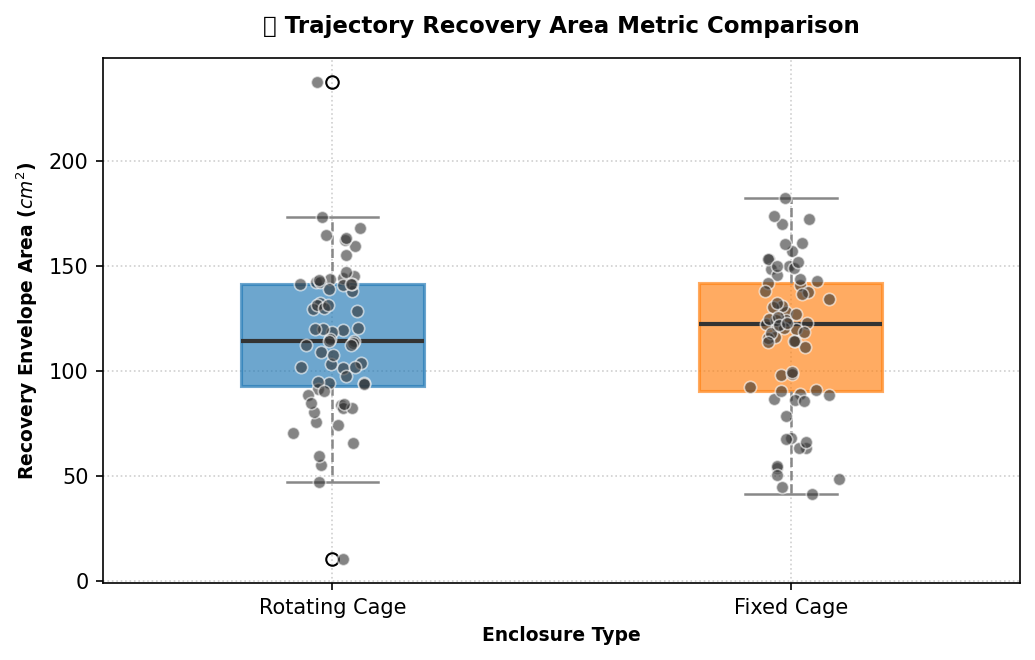

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

# 💡 SWAP THIS variable to any pre-filtered loader to plot instantly!
plot_data_recovery = df_impacts.dropna(subset=['recovery_area'])

# Filter data specifically for box boundaries
box_groups = ['Rotating Cage', 'Fixed Cage']
box_data = [
    plot_data_recovery[plot_data_recovery['condition'] == name]['recovery_area']
    for name in box_groups
]

# Render beautiful boxplots using pure Matplotlib
bp = ax.boxplot(box_data, labels=box_groups, patch_artist=True, widths=0.4, zorder=3)

# Style the boxes
colors_list = ['#1F77B4', '#FF7F0E']
for patch, color in zip(bp['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
    patch.set_edgecolor(color)
    patch.set_linewidth(1.5)

# Style whiskers, caps, and medians cleanly
for median in bp['medians']:
    median.set(color='#333333', linewidth=2.0)
for cap in bp['caps']:
    cap.set(color='#888888', linewidth=1.2)
for whisker in bp['whiskers']:
    whisker.set(color='#888888', linewidth=1.2, linestyle='--')

# Draw scatter jitter points on top of boxes using pure matplotlib
for i, name in enumerate(box_groups, 1):
    vals = plot_data_recovery[plot_data_recovery['condition'] == name]['recovery_area']
    if not vals.empty:
        x_jitter = np.random.normal(i, 0.04, size=len(vals))
        ax.scatter(
            x_jitter,
            vals,
            color='#333333',
            s=35,
            alpha=0.6,
            edgecolor='w',
            linewidth=0.8,
            zorder=4
        )

ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
ax.set_title('📐 Trajectory Recovery Area Metric Comparison', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Enclosure Type', fontsize=9, fontweight='bold')
ax.set_ylabel('Recovery Envelope Area ($cm^2$)', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('graphics/recovery_area_comparison.png', dpi=300)
plt.show()

---

## 🔋 Step 7: Deviation vs. Impact Angle color-coded by Battery State (Rotating Cage)

Below is the visualization plotting **Average Deviation After Contact ($cm$)** against the actual **Impact Angle ($0^\circ$ to $90^\circ$)** for Rotating Cage flights. The dots are color-coded in 4 battery bins representing start LiPo battery states, moving from red (low) to green (full). Clean linear best-fit lines of matching colors are overlaid for each battery bin.

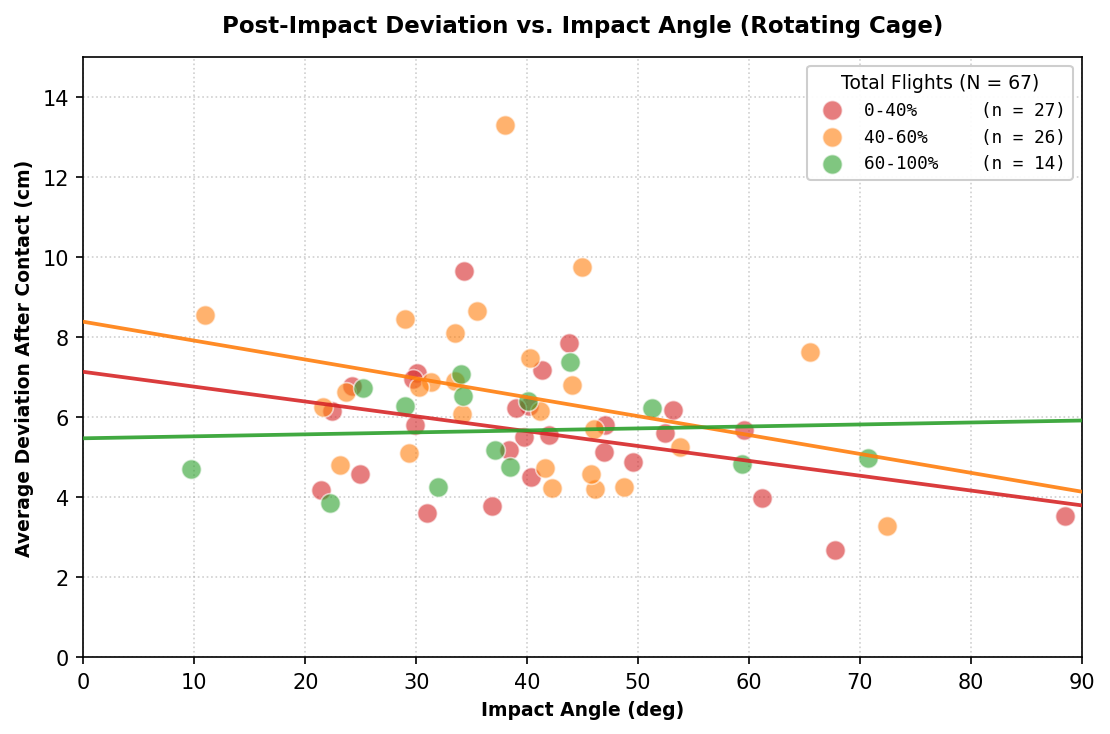

In [7]:
# Filter Rotating Cage impact flights and drop missing deviations, angles, or battery parameters
plot_data_bat = df_rot.dropna(subset=['avg_dev_after', 'impact_angle', 'battery_at_start'])

fig, ax = plt.subplots(figsize=(7.5, 5), dpi=150)

# Define battery bins with corresponding colors and ranges
battery_bins = [
    (0.0, 40.0, '#D62728', '0-40%'),
    (40.0, 60.0, '#FF7F0E', '40-60%'),
    (60.0, 100.0, '#2CA02C', '60-100%')
]

n_total = len(plot_data_bat)

# Render each battery bin series and plot its matching colored trendline
for low, high, color, label_range in battery_bins:
    if low == 0:
        sub = plot_data_bat[(plot_data_bat['battery_at_start'] >= low) & (plot_data_bat['battery_at_start'] <= high)]
    else: 
        sub = plot_data_bat[(plot_data_bat['battery_at_start'] > low) & (plot_data_bat['battery_at_start'] <= high)]
        
    n_sub = len(sub)
    label_text = f"{label_range:<10} (n = {n_sub})"
    
    if not sub.empty:
        # Scatter points
        ax.scatter(
            sub['impact_angle'],
            sub['avg_dev_after'] / 10.0,
            color=color,
            s=90,
            alpha=0.6,
            edgecolor='w',
            linewidth=0.8,
            label=label_text,
            zorder=3
        )
        # Colored Linear Trendlines for each battery bin (n > 1)
        if n_sub > 1:
            x_vals = sub['impact_angle']
            y_vals = sub['avg_dev_after'] / 10.0
            m_bin, c_bin = np.polyfit(x_vals, y_vals, 1)
            x_grid = np.linspace(0, 90, 100)
            ax.plot(
                x_grid,
                m_bin * x_grid + c_bin,
                color=color,
                linestyle='-',
                linewidth=1.8,
                alpha=0.9,
                zorder=4
            )

ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
ax.set_xlim(0, 90)

# Hardcode Y limit strictly from 0 to 15 cm
ax.set_ylim(0, 15)

ax.set_title('Post-Impact Deviation vs. Impact Angle (Rotating Cage)', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Impact Angle (deg)', fontsize=9, fontweight='bold')
ax.set_ylabel('Average Deviation After Contact (cm)', fontsize=9, fontweight='bold')

# Premium SSoT legend mapping with cumulative total at top
ax.legend(
    title=f'Total Flights (N = {n_total})',
    title_fontsize='9',
    loc='best',
    framealpha=0.95,
    prop={'family': 'monospace', 'size': 8.5}
)

plt.tight_layout()
plt.savefig('graphics/rotating_cage_dev_vs_angle_battery.png', dpi=300)
plt.show()


---

## 🔋 Step 8: Deviation vs. Impact Angle color-coded by Battery State (Fixed Cage)

Below is the visualization plotting **Average Deviation After Contact ($cm$)** against the actual **Impact Angle ($0^\circ$ to $90^\circ$)** for Fixed Cage flights. The dots are color-coded in 4 battery bins representing start LiPo battery states, moving from red (low) to green (full). Clean linear best-fit lines of matching colors are overlaid for each battery bin.

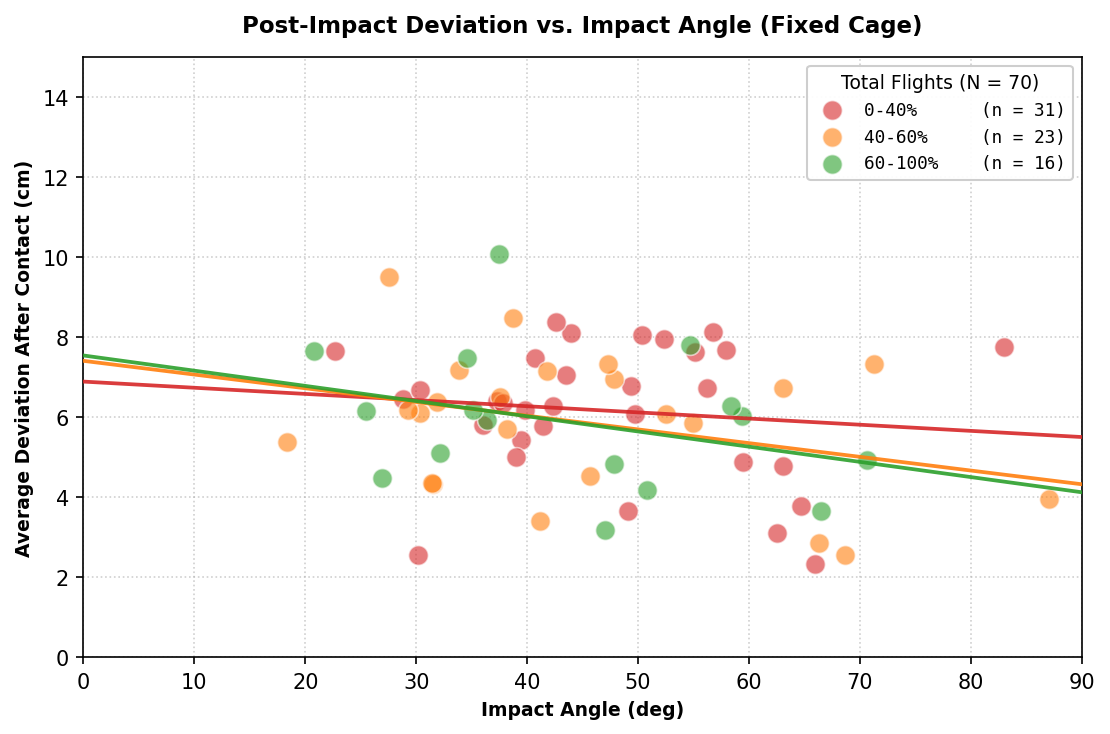

In [8]:
# Filter Fixed Cage impact flights and drop missing deviations, angles, or battery parameters
plot_data_bat_fix = df_fix.dropna(subset=['avg_dev_after', 'impact_angle', 'battery_at_start'])

fig, ax = plt.subplots(figsize=(7.5, 5), dpi=150)

# Define battery bins with corresponding colors and ranges
battery_bins = [
    (0.0, 40.0, '#D62728', '0-40%'),
    (40.0, 60.0, '#FF7F0E', '40-60%'),
    (60.0, 100.0, '#2CA02C', '60-100%')
]

n_total_fix = len(plot_data_bat_fix)

# Render each battery bin series and plot its matching colored trendline
for low, high, color, label_range in battery_bins:
    if low == 0:
        sub = plot_data_bat_fix[(plot_data_bat_fix['battery_at_start'] >= low) & (plot_data_bat_fix['battery_at_start'] <= high)]
    else: 
        sub = plot_data_bat_fix[(plot_data_bat_fix['battery_at_start'] > low) & (plot_data_bat_fix['battery_at_start'] <= high)]
        
    n_sub = len(sub)
    label_text = f"{label_range:<10} (n = {n_sub})"
    
    if not sub.empty:
        # Scatter points
        ax.scatter(
            sub['impact_angle'],
            sub['avg_dev_after'] / 10.0,
            color=color,
            s=90,
            alpha=0.6,
            edgecolor='w',
            linewidth=0.8,
            label=label_text,
            zorder=3
        )
        # Colored Linear Trendlines for each battery bin (n > 1)
        if n_sub > 1:
            x_vals = sub['impact_angle']
            y_vals = sub['avg_dev_after'] / 10.0
            m_bin, c_bin = np.polyfit(x_vals, y_vals, 1)
            x_grid = np.linspace(0, 90, 100)
            ax.plot(
                x_grid,
                m_bin * x_grid + c_bin,
                color=color,
                linestyle='-',
                linewidth=1.8,
                alpha=0.9,
                zorder=4
            )

ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
ax.set_xlim(0, 90)

# Hardcode Y limit strictly from 0 to 15 cm
ax.set_ylim(0, 15)

ax.set_title('Post-Impact Deviation vs. Impact Angle (Fixed Cage)', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Impact Angle (deg)', fontsize=9, fontweight='bold')
ax.set_ylabel('Average Deviation After Contact (cm)', fontsize=9, fontweight='bold')

# Premium SSoT legend mapping with cumulative total at top
ax.legend(
    title=f'Total Flights (N = {n_total_fix})',
    title_fontsize='9',
    loc='best',
    framealpha=0.95,
    prop={'family': 'monospace', 'size': 8.5}
)

plt.tight_layout()
plt.savefig('graphics/fixed_cage_dev_vs_angle_battery.png', dpi=300)
plt.show()


---

## 📈 Step 9: Comparative Stabilization Overlay (Rotating vs. Fixed Cage)

Below is the final publication overlay plotting the actual **Average Deviation After Contact ($cm$)** against **Impact Angle ($0^\circ$ to $90^\circ$)** for both safety enclosures. It overlays their linear trendlines (dashed line for Rotating Cage, solid line for Fixed Cage) to mathematically prove contact dynamics comparison.

/tmp/ipykernel_80547/3326193468.py:100: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_80547/3326193468.py:100: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_80547/3326193468.py:101: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('graphics/comparative_cage_deviation_overlay.png', dpi=300)
/tmp/ipykernel_80547/3326193468.py:101: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('graphics/comparative_cage_deviation_overlay.png', dpi=300)
/home/dorten/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **k

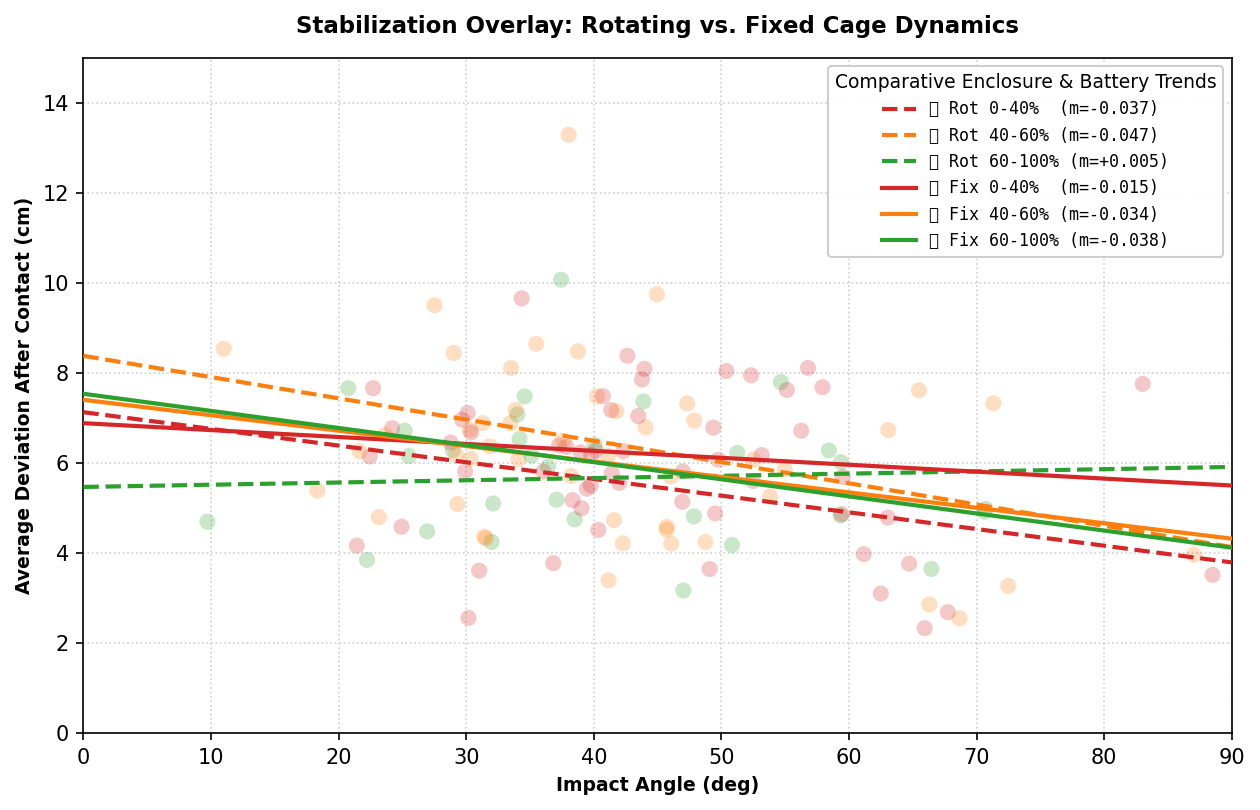

In [9]:
# Filter and drop missing values for both configurations
plot_rot = df_rot.dropna(subset=['avg_dev_after', 'impact_angle', 'battery_at_start'])
plot_fix = df_fix.dropna(subset=['avg_dev_after', 'impact_angle', 'battery_at_start'])

fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=150)

# Define battery bins with corresponding colors and ranges
battery_bins = [
    (0.0, 40.0, '#D62728', '0-40%'),
    (40.0, 60.0, '#FF7F0E', '40-60%'),
    (60.0, 100.0, '#2CA02C', '60-100%')
]

# 1. Plot Rotating Cage dots lightly and fit 4 trendlines (Dashed Lines)
for low, high, color, label_range in battery_bins:
    if low == 0:
        sub_rot = plot_rot[(plot_rot['battery_at_start'] >= low) & (plot_rot['battery_at_start'] <= high)]
    else:
        sub_rot = plot_rot[(plot_rot['battery_at_start'] > low) & (plot_rot['battery_at_start'] <= high)]
        
    n_sub = len(sub_rot)
    if not sub_rot.empty:
        # Scatter points (lightly in background)
        ax.scatter(
            sub_rot['impact_angle'],
            sub_rot['avg_dev_after'] / 10.0,
            color=color,
            s=60,
            alpha=0.25,
            edgecolor='none',
            zorder=2
        )
        # Fit Dashed Trendline (n > 1)
        if n_sub > 1:
            x_vals = sub_rot['impact_angle']
            y_vals = sub_rot['avg_dev_after'] / 10.0
            m_rot, c_rot = np.polyfit(x_vals, y_vals, 1)
            x_grid = np.linspace(0, 90, 100)
            ax.plot(
                x_grid,
                m_rot * x_grid + c_rot,
                color=color,
                linestyle='--',
                linewidth=2.0,
                label=f"🔄 Rot {label_range:<6} (m={m_rot:+.3f})",
                zorder=4
            )

# 2. Plot Fixed Cage dots lightly and fit 4 trendlines (Solid Lines)
for low, high, color, label_range in battery_bins:
    if low == 0:
        sub_fix = plot_fix[(plot_fix['battery_at_start'] >= low) & (plot_fix['battery_at_start'] <= high)]
    else:
        sub_fix = plot_fix[(plot_fix['battery_at_start'] > low) & (plot_fix['battery_at_start'] <= high)]
        
    n_sub = len(sub_fix)
    if not sub_fix.empty:
        # Scatter points (lightly in background)
        ax.scatter(
            sub_fix['impact_angle'],
            sub_fix['avg_dev_after'] / 10.0,
            color=color,
            s=60,
            alpha=0.25,
            edgecolor='none',
            zorder=2
        )
        # Fit Solid Trendline (n > 1)
        if n_sub > 1:
            x_vals = sub_fix['impact_angle']
            y_vals = sub_fix['avg_dev_after'] / 10.0
            m_fix, c_fix = np.polyfit(x_vals, y_vals, 1)
            x_grid = np.linspace(0, 90, 100)
            ax.plot(
                x_grid,
                m_fix * x_grid + c_fix,
                color=color,
                linestyle='-',
                linewidth=2.0,
                label=f"🔒 Fix {label_range:<6} (m={m_fix:+.3f})",
                zorder=4
            )

ax.grid(True, linestyle=':', alpha=0.6, zorder=0)
ax.set_xlim(0, 90)
ax.set_ylim(0, 15)

ax.set_title('Stabilization Overlay: Rotating vs. Fixed Cage Dynamics', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Impact Angle (deg)', fontsize=9, fontweight='bold')
ax.set_ylabel('Average Deviation After Contact (cm)', fontsize=9, fontweight='bold')

ax.legend(
    title='Comparative Enclosure & Battery Trends',
    title_fontsize='9',
    loc='upper right',
    framealpha=0.95,
    prop={'family': 'monospace', 'size': 8.0}
)

plt.tight_layout()
plt.savefig('graphics/comparative_cage_deviation_overlay.png', dpi=300)
plt.show()


---

## 🔋 Step 10: Battery & Flight Efficiency Comparative Analysis

To evaluate the hypothesis that the **Rotating Cage** configuration is more energy-efficient than the **Fixed Cage** configuration, this section analyzes raw flight logs across the entire database. We compare:
1. **Total Active Flying Duration ($s$)**: The time between takeoff and landing.
2. **Mean Voltage Sag under Flying Load ($V$)**: The average battery voltage while active.
3. **Battery Capacity Consumption Rate ($\%/min$)**: The rate of charge drop.
4. **Voltage Drop Rate ($V/min$)**: The rate of voltage drop.

A lower capacity consumption rate ($\%/min$) mathematically proves the rotating cage configuration requires less battery/stabilization effort.


### 📊 Enclosure Comparative Energy Metrics Summary


,Flights Count,Mean Flying Time (s),Flying Time Std (s),Mean Flying Voltage (V),Capacity Drain Rate (%/min),Voltage Drop Rate (V/min)
condition,,,,,,
Fixed Cage,19,90.038,75.610,22.596,25.039,0.453
Rotating Cage,12,90.568,47.491,22.422,26.387,0.679


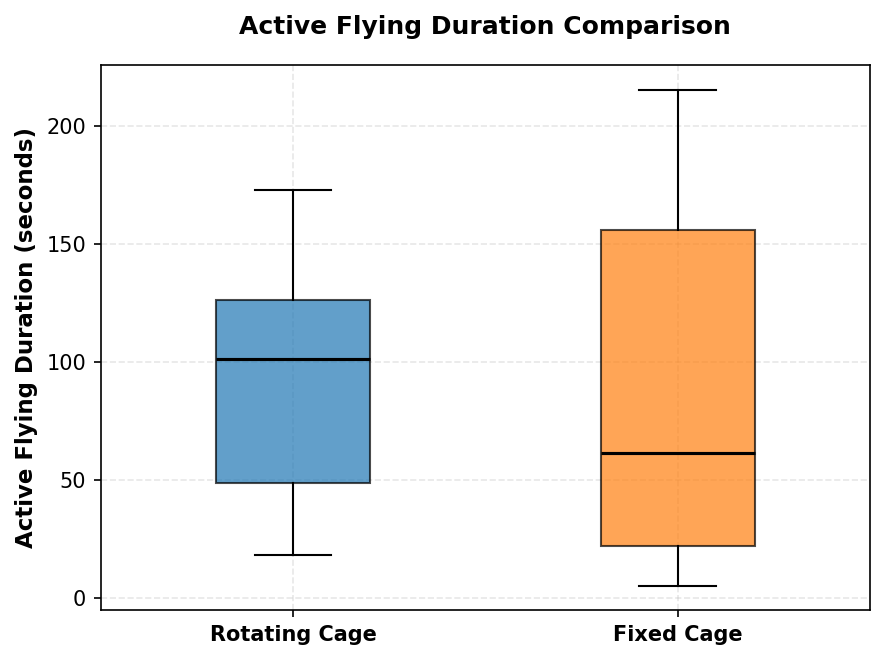

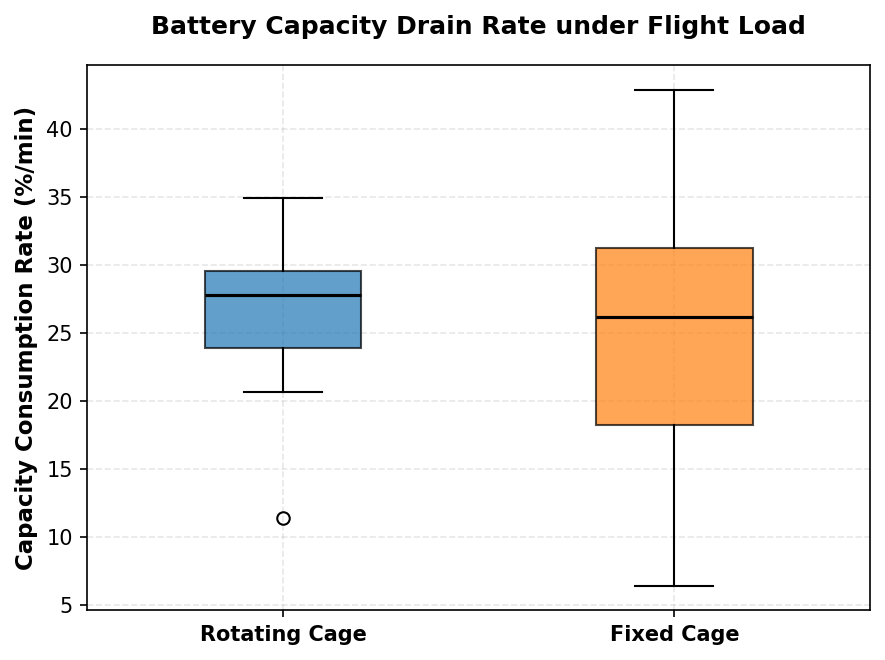

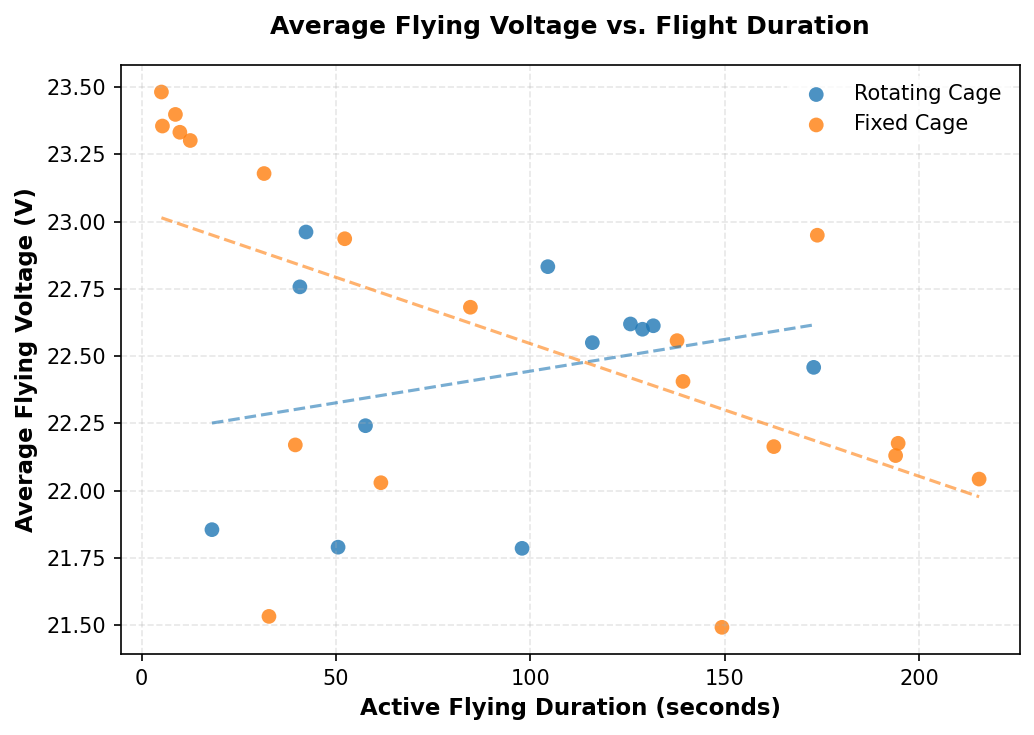

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dev_logs.analysis.database.db_manager import get_battery_efficiency_df

# Load the efficiency dataset
df_eff = get_battery_efficiency_df()

# Drop rows with invalid conditions or flying time <= 0
df_eff = df_eff[df_eff['total_flying_time'] > 0]

# Print markdown comparative summary table
print("### 📊 Enclosure Comparative Energy Metrics Summary")
summary = df_eff.groupby('condition').agg({
    'total_flying_time': ['count', 'mean', 'std'],
    'avg_voltage_during_flight': 'mean',
    'capacity_drain_rate_flying': 'mean',
    'voltage_drop_rate_flying': 'mean'
})
# Rename columns nicely
summary.columns = [
    'Flights Count', 'Mean Flying Time (s)', 'Flying Time Std (s)',
    'Mean Flying Voltage (V)', 'Capacity Drain Rate (%/min)', 'Voltage Drop Rate (V/min)'
]
display(summary.round(3))

# Define clean color palette matching dashboard SSoT
color_rot = '#1F77B4' # Sleek Blue
color_fix = '#FF7F0E' # Vibrant Orange

# --- PLOT 10A: Active Flying Time ---
fig1, ax1 = plt.subplots(figsize=(6, 4.5), dpi=150)
box1 = ax1.boxplot([
    df_eff[df_eff['condition'] == 'Rotating Cage']['total_flying_time'],
    df_eff[df_eff['condition'] == 'Fixed Cage']['total_flying_time']
], patch_artist=True, widths=0.4, medianprops=dict(color='black', linewidth=1.5))

colors = [color_rot, color_fix]
for patch, color in zip(box1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax1.set_xticklabels(['Rotating Cage', 'Fixed Cage'], fontweight='bold')
ax1.set_ylabel('Active Flying Duration (seconds)', fontsize=11, fontweight='bold')
ax1.set_title('Active Flying Duration Comparison', fontsize=12, fontweight='bold', pad=15)
ax1.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
fig1.savefig('graphics/plot_10a_flying_duration.png', bbox_inches='tight')
plt.show()

# --- PLOT 10B: Capacity Consumption Rate (%/min) ---
fig2, ax2 = plt.subplots(figsize=(6, 4.5), dpi=150)
box2 = ax2.boxplot([
    df_eff[df_eff['condition'] == 'Rotating Cage']['capacity_drain_rate_flying'],
    df_eff[df_eff['condition'] == 'Fixed Cage']['capacity_drain_rate_flying']
], patch_artist=True, widths=0.4, medianprops=dict(color='black', linewidth=1.5))

for patch, color in zip(box2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_xticklabels(['Rotating Cage', 'Fixed Cage'], fontweight='bold')
ax2.set_ylabel('Capacity Consumption Rate (%/min)', fontsize=11, fontweight='bold')
ax2.set_title('Battery Capacity Drain Rate under Flight Load', fontsize=12, fontweight='bold', pad=15)
ax2.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
fig2.savefig('graphics/plot_10b_capacity_drain_rate.png', bbox_inches='tight')
plt.show()

# --- PLOT 10C: Voltage Sag / Duration Scatter ---
fig3, ax3 = plt.subplots(figsize=(7, 5), dpi=150)
df_rot_scatter = df_eff[df_eff['condition'] == 'Rotating Cage']
df_fix_scatter = df_eff[df_eff['condition'] == 'Fixed Cage']

ax3.scatter(df_rot_scatter['total_flying_time'], df_rot_scatter['avg_voltage_during_flight'], 
            color=color_rot, alpha=0.8, edgecolors='none', s=50, label='Rotating Cage')
ax3.scatter(df_fix_scatter['total_flying_time'], df_fix_scatter['avg_voltage_during_flight'], 
            color=color_fix, alpha=0.8, edgecolors='none', s=50, label='Fixed Cage')

# Fit linear trendlines for visual correlation
for df_sub, color in [(df_rot_scatter, color_rot), (df_fix_scatter, color_fix)]:
    if len(df_sub) > 1:
        z = np.polyfit(df_sub['total_flying_time'], df_sub['avg_voltage_during_flight'], 1)
        p = np.poly1d(z)
        xp = np.linspace(df_sub['total_flying_time'].min(), df_sub['total_flying_time'].max(), 100)
        ax3.plot(xp, p(xp), color=color, linestyle='--', alpha=0.6, linewidth=1.5)

ax3.set_xlabel('Active Flying Duration (seconds)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Average Flying Voltage (V)', fontsize=11, fontweight='bold')
ax3.set_title('Average Flying Voltage vs. Flight Duration', fontsize=12, fontweight='bold', pad=15)
ax3.legend(frameon=True, facecolor='white', edgecolor='none')
ax3.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
fig3.savefig('graphics/plot_10c_voltage_vs_duration.png', bbox_inches='tight')
plt.show()


---

## 🔋 Step 11: Deceleration vs. Battery State color-coded by Impact Angle (Rotating vs. Fixed Cage)

To understand how the **maximum deceleration magnitude** behaves under different battery states and collision impact angles, we map the deceleration spike ($m/s^2$) against the start LiPo battery percentage ($\%$). 

The dots are color-coded based on the actual **Impact Angle ($0^\circ$ to $90^\circ$)** along a continuous Red-to-Green spectrum:
- **Red ($0^\circ$)**: Direct, head-on/orthogonal perpendicular impact, causing extreme deceleration.
- **Green ($90^\circ$)**: Glancing/parallel brushing impact, showing minimal deceleration.

Linear trendlines are fit globally for each cage type to highlight the overall relationship between start battery charge level and impact dynamics.


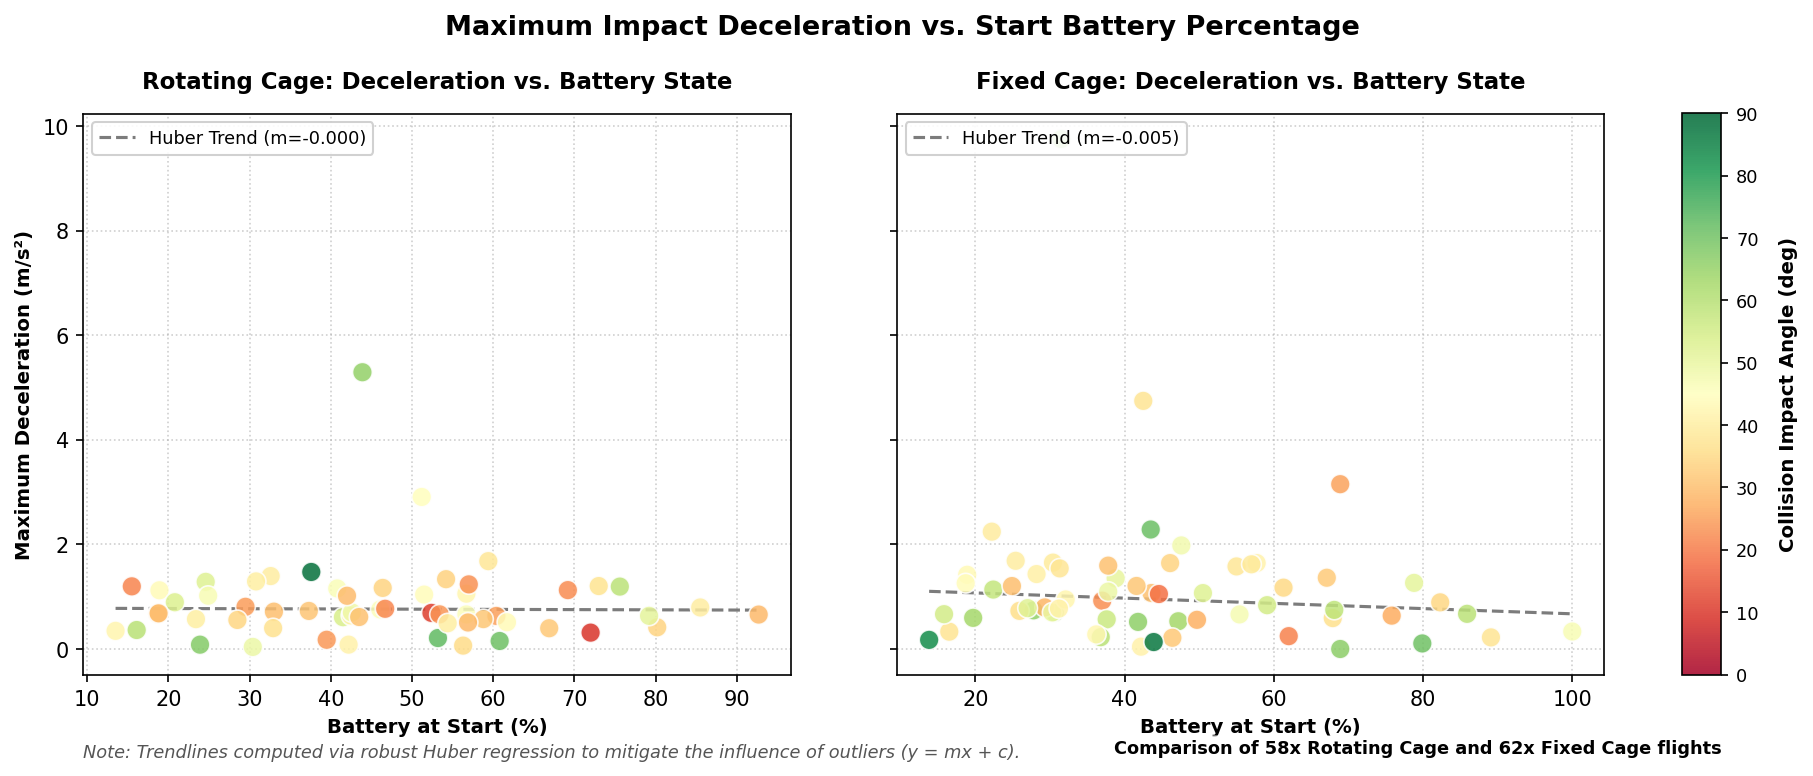

In [11]:
import sys, os
project_root = os.path.abspath(os.path.join(os.path.abspath(''), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from dev_logs.analysis.database.db_manager import get_database_df

def huber_regressor(x, y, delta=1.345, max_iter=100, tol=1e-5):
    import numpy as np
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    X = np.vstack([x, np.ones_like(x)]).T
    # Initial OLS fit
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    for _ in range(max_iter):
        predictions = X @ beta
        residuals = y - predictions
        mad = np.median(np.abs(residuals - np.median(residuals)))
        scale = mad / 0.6745 if mad > 1e-5 else 1.0
        u = residuals / scale
        w = np.where(np.abs(u) <= delta, 1.0, delta / np.abs(u))
        beta_new = np.linalg.solve(X.T @ (w[:, None] * X), X.T @ (w * y))
        if np.linalg.norm(beta_new - beta) < tol:
            beta = beta_new
            break
        beta = beta_new
    return beta[0], beta[1]


# Load the flights database
df_all = get_database_df()

# Filter only flights where an impact was detected
df_impacts = df_all.query("impact_detected == 1").copy()

# Compute deceleration magnitude (absolute value of tangential acceleration at impact)
df_impacts['deceleration'] = df_impacts['impact_accel'].abs()

# Clean missing parameters
plot_data = df_impacts.dropna(subset=['deceleration', 'battery_at_start', 'impact_angle'])

# Subset by cage type
df_rot = plot_data.query("condition == 'Rotating Cage'")
df_fix = plot_data.query("condition == 'Fixed Cage'")

# Create premium double-panel visualization matching SSoT style
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True, dpi=150)

# Colormap normalization (Red @ 0 deg, Green @ 90 deg)
norm = plt.Normalize(0, 90)
cmap = plt.cm.RdYlGn

# 1. Rotating Cage Subplot
sc1 = ax1.scatter(
    df_rot['battery_at_start'],
    df_rot['deceleration'],
    c=df_rot['impact_angle'],
    cmap=cmap,
    norm=norm,
    s=90,
    alpha=0.85,
    edgecolor='w',
    linewidth=0.8,
    zorder=3
)

# Fit linear trendline for Rotating Cage
if len(df_rot) > 1:
    m_rot, c_rot = huber_regressor(df_rot['battery_at_start'], df_rot['deceleration'])
    x_rot = np.linspace(df_rot['battery_at_start'].min(), df_rot['battery_at_start'].max(), 100)
    ax1.plot(x_rot, m_rot * x_rot + c_rot, color='#444444', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Huber Trend (m={m_rot:.3f})')
    ax1.legend(loc='upper left', fontsize=8.5, framealpha=0.9)

ax1.set_title('Rotating Cage: Deceleration vs. Battery State', fontsize=11, fontweight='bold', pad=12)
ax1.set_xlabel('Battery at Start (%)', fontsize=9.5, fontweight='bold')
ax1.set_ylabel('Maximum Deceleration (m/s²)', fontsize=9.5, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6, zorder=0)

# 2. Fixed Cage Subplot
sc2 = ax2.scatter(
    df_fix['battery_at_start'],
    df_fix['deceleration'],
    c=df_fix['impact_angle'],
    cmap=cmap,
    norm=norm,
    s=90,
    alpha=0.85,
    edgecolor='w',
    linewidth=0.8,
    zorder=3
)

# Fit linear trendline for Fixed Cage
if len(df_fix) > 1:
    m_fix, c_fix = huber_regressor(df_fix['battery_at_start'], df_fix['deceleration'])
    x_fix = np.linspace(df_fix['battery_at_start'].min(), df_fix['battery_at_start'].max(), 100)
    ax2.plot(x_fix, m_fix * x_fix + c_fix, color='#444444', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Huber Trend (m={m_fix:.3f})')
    ax2.legend(loc='upper left', fontsize=8.5, framealpha=0.9)

ax2.set_title('Fixed Cage: Deceleration vs. Battery State', fontsize=11, fontweight='bold', pad=12)
ax2.set_xlabel('Battery at Start (%)', fontsize=9.5, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6, zorder=0)

# Clean Title (Single Line)
fig.suptitle('Maximum Impact Deceleration vs. Start Battery Percentage', fontsize=13, fontweight='bold', y=0.95)

# Warning-free precise layout adjustment
fig.subplots_adjust(left=0.08, right=0.86, bottom=0.15, top=0.83, wspace=0.15)

# Dedicated Colorbar Axes to prevent interference/overlap completely
cax = fig.add_axes([0.90, 0.15, 0.02, 0.68])
cbar = fig.colorbar(sc2, cax=cax)
cbar.set_label('Collision Impact Angle (deg)', fontsize=9.5, fontweight='bold', labelpad=10)
cbar.ax.tick_params(labelsize=8.5)

# Footnote/subtitle for regression lines
fig.text(0.08, 0.05, "Note: Trendlines computed via robust Huber regression to mitigate the influence of outliers (y = mx + c).",
         fontsize=8.5, fontstyle='italic', color='#555555')

# Add dynamic data origin label
n_rot_total = df_rot.shape[0]
n_fix_total = df_fix.shape[0]
fig.text(0.92, 0.05, f"Comparison of {n_rot_total}x Rotating Cage and {n_fix_total}x Fixed Cage flights",
         ha='right', va='bottom', fontsize=8.5, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

os.makedirs('graphics', exist_ok=True)
plt.savefig('graphics/deceleration_vs_battery_angle.png', dpi=300, bbox_inches='tight')
plt.show()


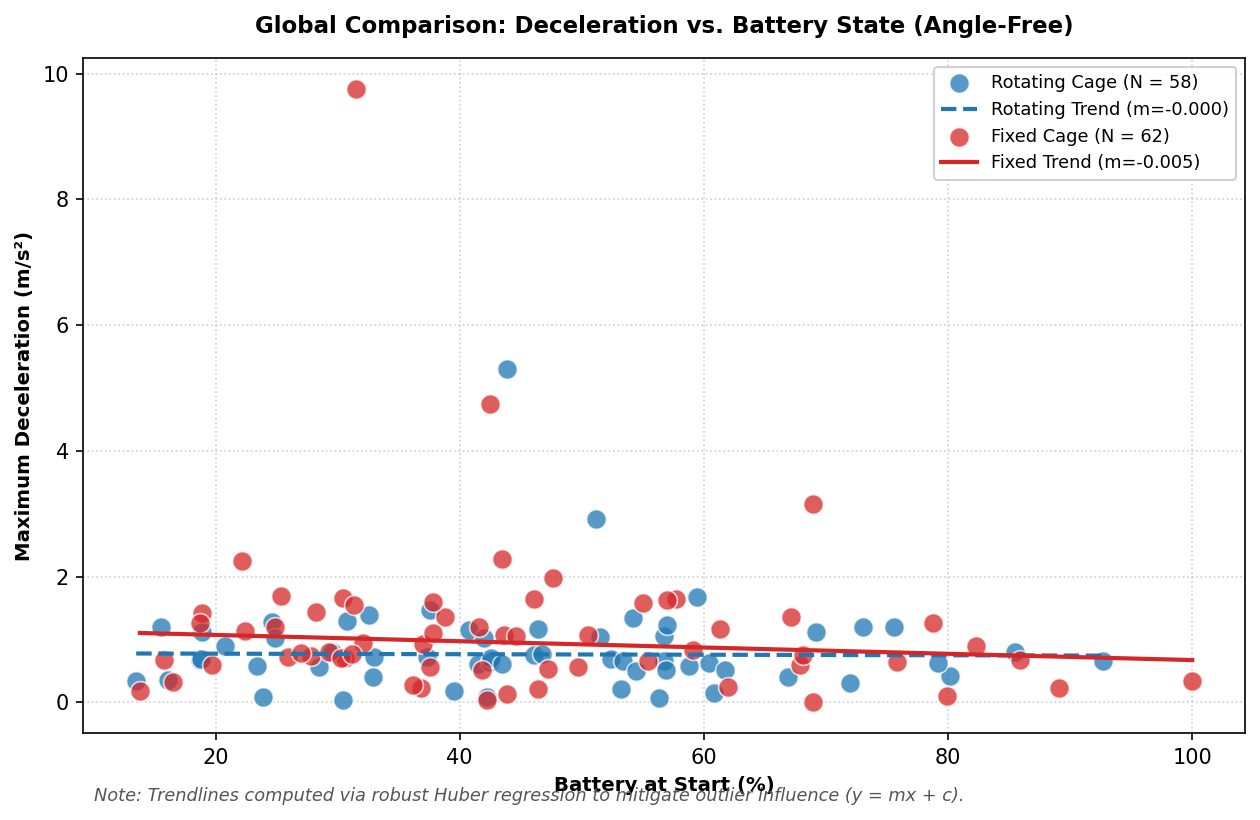

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from dev_logs.analysis.database.db_manager import get_database_df

# Load the flights database
df_all = get_database_df()

# Filter only flights where an impact was detected
df_impacts = df_all.query("impact_detected == 1").copy()

# Compute deceleration magnitude
df_impacts['deceleration'] = df_impacts['impact_accel'].abs()

# Clean missing parameters
plot_data = df_impacts.dropna(subset=['deceleration', 'battery_at_start'])

# Subset by cage type
df_rot = plot_data.query("condition == 'Rotating Cage'")
df_fix = plot_data.query("condition == 'Fixed Cage'")

# Create premium single-panel visualization matching SSoT style
fig, ax = plt.subplots(figsize=(8.5, 5.5), dpi=150)

# Colors matching dashboard SSoT
color_rot = '#1F77B4' # Sleek Blue
color_fix = '#D62728' # Vibrant Red

# 1. Rotating Cage Scatter
ax.scatter(
    df_rot['battery_at_start'],
    df_rot['deceleration'],
    color=color_rot,
    s=90,
    alpha=0.75,
    edgecolor='w',
    linewidth=0.8,
    label=f'Rotating Cage (N = {len(df_rot)})',
    zorder=3
)

# Fit robust Huber trendline for Rotating Cage
if len(df_rot) > 1:
    m_rot, c_rot = huber_regressor(df_rot['battery_at_start'], df_rot['deceleration'])
    x_rot = np.linspace(df_rot['battery_at_start'].min(), df_rot['battery_at_start'].max(), 100)
    ax.plot(
        x_rot,
        m_rot * x_rot + c_rot,
        color=color_rot,
        linestyle='--',
        linewidth=2.0,
        label=f'Rotating Trend (m={m_rot:+.3f})',
        zorder=4
    )

# 2. Fixed Cage Scatter
ax.scatter(
    df_fix['battery_at_start'],
    df_fix['deceleration'],
    color=color_fix,
    s=90,
    alpha=0.75,
    edgecolor='w',
    linewidth=0.8,
    label=f'Fixed Cage (N = {len(df_fix)})',
    zorder=3
)

# Fit robust Huber trendline for Fixed Cage
if len(df_fix) > 1:
    m_fix, c_fix = huber_regressor(df_fix['battery_at_start'], df_fix['deceleration'])
    x_fix = np.linspace(df_fix['battery_at_start'].min(), df_fix['battery_at_start'].max(), 100)
    ax.plot(
        x_fix,
        m_fix * x_fix + c_fix,
        color=color_fix,
        linestyle='-',
        linewidth=2.0,
        label=f'Fixed Trend (m={m_fix:+.3f})',
        zorder=4
    )

ax.set_title('Global Comparison: Deceleration vs. Battery State (Angle-Free)', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel('Battery at Start (%)', fontsize=9.5, fontweight='bold')
ax.set_ylabel('Maximum Deceleration (m/s²)', fontsize=9.5, fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.6, zorder=0)

# Legend configuration
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)

# Footnote/subtitle for regression lines
fig.text(0.08, 0.02, "Note: Trendlines computed via robust Huber regression to mitigate outlier influence (y = mx + c).",
         fontsize=8.5, fontstyle='italic', color='#555555')

plt.tight_layout()
os.makedirs('graphics', exist_ok=True)
plt.savefig('graphics/deceleration_vs_battery_global.png', dpi=300, bbox_inches='tight')
plt.show()


---

## 🏗️ Step 12: Enclosure Structural Dynamics

Comprehensive structural evaluation, containing comparative tables, kinematics, and trajectory paths.

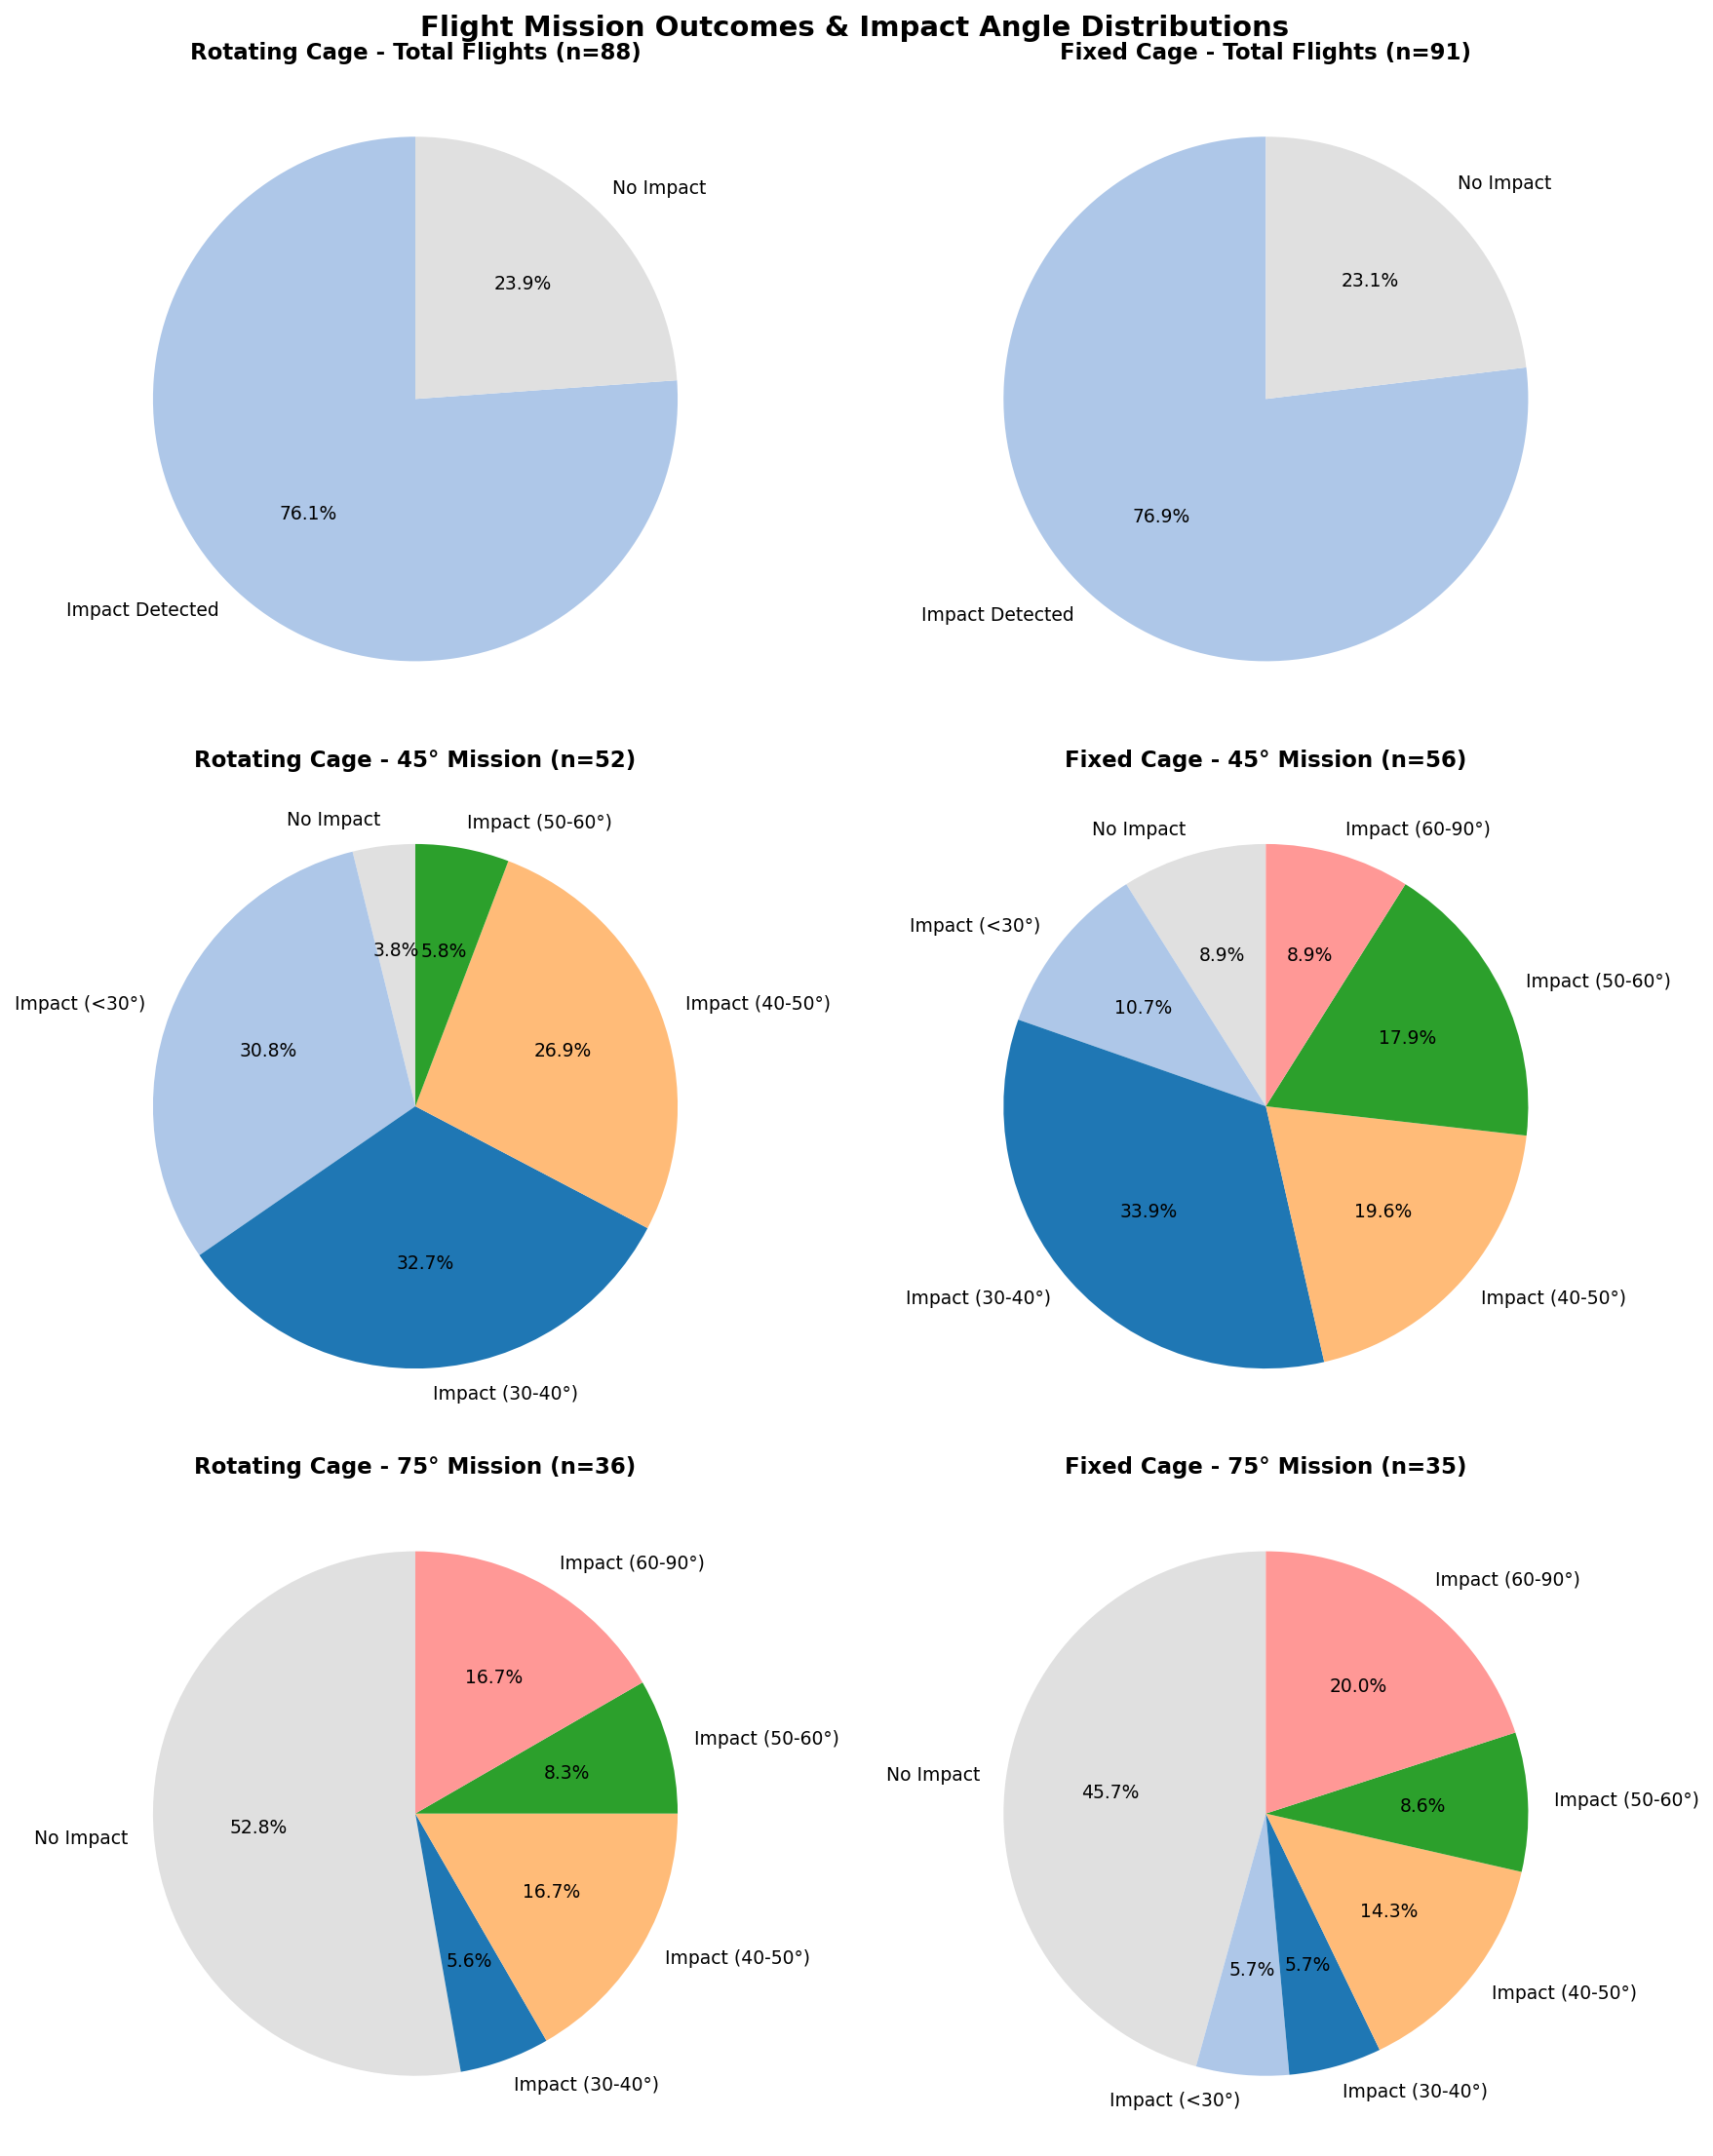

### Enclosure Comparative Table of Averages
Data Origin: Comparison of 51x Rotating Cage and 62x Fixed Cage flights


angle_bin,condition,N-Flights,Avg RPM max,Avg Amp Draw,Avg Voltage Drop,IMU Max Spikes (Accel),IMU Max Spikes (Gyro),Average Deviation Max (mm),Average Recovery Area (mm*m),Avg Thrust Surge,Avg Motor Imbalance
30-40°,Fixed Cage,21,N/A,N/A,N/A,15.37,2.66,119.40,120.89,0.03,0.15
30-40°,Rotating Cage,19,N/A,N/A,N/A,10.48,1.45,140.61,130.76,0.02,0.08
40-50°,Fixed Cage,16,N/A,N/A,N/A,10.38,2.24,118.97,118.74,0.02,0.14
40-50°,Rotating Cage,20,N/A,N/A,N/A,7.63,1.19,126.24,108.68,0.02,0.06
50-60°,Fixed Cage,13,N/A,N/A,N/A,6.22,1.71,138.26,129.52,0.01,0.14
50-60°,Rotating Cage,6,N/A,N/A,N/A,5.20,0.78,125.25,106.80,0.02,0.03
60-90°,Fixed Cage,12,N/A,N/A,N/A,2.61,1.21,88.73,78.59,0.00,0.10
60-90°,Rotating Cage,6,N/A,N/A,N/A,2.21,0.36,82.06,75.76,0.01,0.02


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dev_logs.analysis.database.db_manager import get_database_df
from IPython.display import display, HTML
import os

# Load the flights database
df_all = get_database_df()

# Add mission type
df_all['mission_type'] = df_all['flight_name'].apply(lambda x: '45°' if '45°' in x else ('75°' if '75°' in x else 'Other'))

# Categorize outcome
def categorize_outcome(row):
    if row['impact_detected'] == 0:
        return 'No Impact'
    angle = row['impact_angle']
    if pd.isna(angle):
        return 'Impact (Unknown Angle)'
    if angle < 30:
        return 'Impact (<30°)'
    elif angle < 40:
        return 'Impact (30-40°)'
    elif angle < 50:
        return 'Impact (40-50°)'
    elif angle < 60:
        return 'Impact (50-60°)'
    else:
        return 'Impact (60-90°)'

df_all['outcome'] = df_all.apply(categorize_outcome, axis=1)

# Generate 6 pie charts in a 3x2 grid
fig, axes = plt.subplots(3, 2, figsize=(12, 15), dpi=150)

# Colors mapping
colors_map = {
    'No Impact': '#e0e0e0',
    'Impact (<30°)': '#aec7e8',
    'Impact (30-40°)': '#1f77b4',
    'Impact (40-50°)': '#ffbb78',
    'Impact (50-60°)': '#2ca02c',
    'Impact (60-90°)': '#ff9896',
    'Impact Detected': '#aec7e8'
}

# Row 1: Overall Impact Distribution (Total)
# Rotating Cage Total
rot_total = df_all[df_all['condition'] == 'Rotating Cage']
rot_counts = rot_total['impact_detected'].map({1: 'Impact Detected', 0: 'No Impact'}).value_counts()
axes[0, 0].pie([rot_counts.get('Impact Detected', 0), rot_counts.get('No Impact', 0)], 
               labels=['Impact Detected', 'No Impact'], 
               autopct='%1.1f%%', startangle=90, 
               colors=[colors_map['Impact Detected'], colors_map['No Impact']],
               textprops={'fontsize': 9})
axes[0, 0].set_title(f'Rotating Cage - Total Flights (n={len(rot_total)})', fontsize=11, fontweight='bold')

# Fixed Cage Total
fix_total = df_all[df_all['condition'] == 'Fixed Cage']
fix_counts = fix_total['impact_detected'].map({1: 'Impact Detected', 0: 'No Impact'}).value_counts()
axes[0, 1].pie([fix_counts.get('Impact Detected', 0), fix_counts.get('No Impact', 0)], 
               labels=['Impact Detected', 'No Impact'], 
               autopct='%1.1f%%', startangle=90, 
               colors=[colors_map['Impact Detected'], colors_map['No Impact']],
               textprops={'fontsize': 9})
axes[0, 1].set_title(f'Fixed Cage - Total Flights (n={len(fix_total)})', fontsize=11, fontweight='bold')

# Row 2: 45° Mission Outcomes
# Rotating Cage 45°
rot_45 = df_all[(df_all['condition'] == 'Rotating Cage') & (df_all['mission_type'] == '45°')]
rot_45_counts = rot_45['outcome'].value_counts()
labels_45_rot = [k for k in colors_map.keys() if k in rot_45_counts and k != 'Impact Detected']
vals_45_rot = [rot_45_counts[k] for k in labels_45_rot]
axes[1, 0].pie(vals_45_rot, labels=labels_45_rot, autopct='%1.1f%%', startangle=90,
               colors=[colors_map[k] for k in labels_45_rot], textprops={'fontsize': 9})
axes[1, 0].set_title(f'Rotating Cage - 45° Mission (n={len(rot_45)})', fontsize=11, fontweight='bold')

# Fixed Cage 45°
fix_45 = df_all[(df_all['condition'] == 'Fixed Cage') & (df_all['mission_type'] == '45°')]
fix_45_counts = fix_45['outcome'].value_counts()
labels_45_fix = [k for k in colors_map.keys() if k in fix_45_counts and k != 'Impact Detected']
vals_45_fix = [fix_45_counts[k] for k in labels_45_fix]
axes[1, 1].pie(vals_45_fix, labels=labels_45_fix, autopct='%1.1f%%', startangle=90,
               colors=[colors_map[k] for k in labels_45_fix], textprops={'fontsize': 9})
axes[1, 1].set_title(f'Fixed Cage - 45° Mission (n={len(fix_45)})', fontsize=11, fontweight='bold')

# Row 3: 75° Mission Outcomes
# Rotating Cage 75°
rot_75 = df_all[(df_all['condition'] == 'Rotating Cage') & (df_all['mission_type'] == '75°')]
rot_75_counts = rot_75['outcome'].value_counts()
labels_75_rot = [k for k in colors_map.keys() if k in rot_75_counts and k != 'Impact Detected']
vals_75_rot = [rot_75_counts[k] for k in labels_75_rot]
axes[2, 0].pie(vals_75_rot, labels=labels_75_rot, autopct='%1.1f%%', startangle=90,
               colors=[colors_map[k] for k in labels_75_rot], textprops={'fontsize': 9})
axes[2, 0].set_title(f'Rotating Cage - 75° Mission (n={len(rot_75)})', fontsize=11, fontweight='bold')

# Fixed Cage 75°
fix_75 = df_all[(df_all['condition'] == 'Fixed Cage') & (df_all['mission_type'] == '75°')]
fix_75_counts = fix_75['outcome'].value_counts()
labels_75_fix = [k for k in colors_map.keys() if k in fix_75_counts and k != 'Impact Detected']
vals_75_fix = [fix_75_counts[k] for k in labels_75_fix]
axes[2, 1].pie(vals_75_fix, labels=labels_75_fix, autopct='%1.1f%%', startangle=90,
               colors=[colors_map[k] for k in labels_75_fix], textprops={'fontsize': 9})
axes[2, 1].set_title(f'Fixed Cage - 75° Mission (n={len(fix_75)})', fontsize=11, fontweight='bold')

plt.suptitle('Flight Mission Outcomes & Impact Angle Distributions', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
os.makedirs('graphics', exist_ok=True)
plt.savefig('graphics/plot_13_mission_pies.png', dpi=300, bbox_inches='tight')
plt.show()

# Table of Averages split by collapsed angle bins (30-40, 40-50, 50-60, 60-90)
df_impacts = df_all.query("impact_detected == 1").copy()
bins = [30, 40, 50, 60, 90]
labels_table = ['30-40°', '40-50°', '50-60°', '60-90°']

df_impacts_valid = df_impacts.dropna(subset=['impact_angle']).copy()
df_impacts_valid['angle_bin'] = pd.cut(df_impacts_valid['impact_angle'], bins=bins, labels=labels_table, right=False)
df_impacts_valid.loc[df_impacts_valid['impact_angle'] == 90, 'angle_bin'] = '60-90°'

df_table_data = df_impacts_valid.dropna(subset=['angle_bin']).copy()

# Add placeholder columns for unrecorded data
df_table_data['Avg RPM max'] = np.nan
df_table_data['Avg Amp Draw'] = np.nan
df_table_data['Avg Voltage Drop'] = np.nan

metrics = {
    'flight_name': 'count',
    'Avg RPM max': 'mean',
    'Avg Amp Draw': 'mean',
    'Avg Voltage Drop': 'mean',
    'imu_peak_accel': 'mean',
    'imu_peak_gyro': 'mean',
    'max_dev_after': 'mean',
    'recovery_area': 'mean',
    'motor_thrust_surge': 'mean',
    'motor_imbalance_after': 'mean'
}

df_avg = df_table_data.groupby(['angle_bin', 'condition'], observed=False).agg(metrics).reset_index()

# Rename columns
df_avg.rename(columns={
    'flight_name': 'N-Flights',
    'imu_peak_accel': 'IMU Max Spikes (Accel)',
    'imu_peak_gyro': 'IMU Max Spikes (Gyro)',
    'max_dev_after': 'Average Deviation Max (mm)',
    'recovery_area': 'Average Recovery Area (mm*m)',
    'motor_thrust_surge': 'Avg Thrust Surge',
    'motor_imbalance_after': 'Avg Motor Imbalance'
}, inplace=True)

# Sort by angle_bin and condition so they oscillate
df_avg = df_avg.sort_values(by=['angle_bin', 'condition']).reset_index(drop=True)

# Reorder columns for styling first 4 columns vs metrics
df_avg = df_avg[[
    'angle_bin', 'condition', 'N-Flights', 
    'Avg RPM max', 'Avg Amp Draw', 'Avg Voltage Drop',
    'IMU Max Spikes (Accel)', 'IMU Max Spikes (Gyro)',
    'Average Deviation Max (mm)', 'Average Recovery Area (mm*m)',
    'Avg Thrust Surge', 'Avg Motor Imbalance'
]]

# Helper to convert DataFrame to HTML with inline styles
def render_styled_table(df):
    cols_to_compare = [
        'IMU Max Spikes (Accel)',
        'IMU Max Spikes (Gyro)',
        'Average Deviation Max (mm)',
        'Average Recovery Area (mm*m)',
        'Avg Thrust Surge',
        'Avg Motor Imbalance'
    ]
    
    html = '<table border="1" class="dataframe" style="border-collapse: collapse; text-align: right; font-family: monospace; font-size: 13px;">'
    html += '<tr style="background-color: #f2f2f2; font-weight: bold;">'
    for col in df.columns:
        html += f'<th style="padding: 8px; border: 1px solid #ddd;">{col}</th>'
    html += '</tr>'
    
    for idx, row in df.iterrows():
        bin_val = row['angle_bin']
        cond_val = row['condition']
        sibling_cond = 'Fixed Cage' if cond_val == 'Rotating Cage' else 'Rotating Cage'
        sibling_rows = df[(df['angle_bin'] == bin_val) & (df['condition'] == sibling_cond)]
        
        has_sibling = len(sibling_rows) > 0
        if has_sibling:
            sibling_row = sibling_rows.iloc[0]
            
        html += '<tr>'
        for col_idx, col in enumerate(df.columns):
            val = row[col]
            style = 'padding: 8px; border: 1px solid #ddd;'
            
            if col == 'N-Flights':
                val_str = f"{val:.0f}"
            elif col in ['angle_bin', 'condition']:
                val_str = str(val)
            else:
                if pd.isna(val):
                    val_str = 'N/A'
                else:
                    val_str = f"{val:.2f}"
            
            # First 4 columns style (alternating Blue/Red for Rotating/Fixed)
            if col_idx < 4:
                if cond_val == 'Rotating Cage':
                    style += ' background-color: #d2e4f6; color: #0d233a; font-weight: 500;'
                else:
                    style += ' background-color: #f7d2d2; color: #3d0b0b; font-weight: 500;'
            elif col in cols_to_compare and has_sibling:
                sib_val = sibling_row[col]
                if not pd.isna(val) and not pd.isna(sib_val):
                    better_val = min(val, sib_val)
                    worse_val = max(val, sib_val)
                    ratio = 1.0 - (better_val / worse_val) if worse_val > 0 else 0.0
                    ratio = min(max(ratio, 0.0), 0.8) # Cap ratio at 0.8 to keep text readable
                    
                    if val == sib_val:
                        style += ' background-color: #f9f9f9; color: #333;'
                    elif val < sib_val:
                        l_green = int(95 - 25 * ratio)
                        t_green = int(30 - 15 * ratio)
                        style += f' background-color: hsl(134, 50%, {l_green}%); color: hsl(134, 60%, {t_green}%); font-weight: bold;'
                    else:
                        l_red = int(95 - 20 * ratio)
                        t_red = int(30 - 15 * ratio)
                        style += f' background-color: hsl(0, 65%, {l_red}%); color: hsl(0, 75%, {t_red}%);'
            
            html += f'<td style="{style}">{val_str}</td>'
        html += '</tr>'
    html += '</table>'
    return html

print("### Enclosure Comparative Table of Averages")
n_rot_total = df_table_data[df_table_data['condition'] == 'Rotating Cage'].shape[0]
n_fix_total = df_table_data[df_table_data['condition'] == 'Fixed Cage'].shape[0]
print(f"Data Origin: Comparison of {n_rot_total}x Rotating Cage and {n_fix_total}x Fixed Cage flights")
display(HTML(render_styled_table(df_avg)))


/tmp/ipykernel_80547/2527392564.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp0 = axes[0].boxplot(box_data_accel, labels=box_groups, patch_artist=True, widths=0.4)
/tmp/ipykernel_80547/2527392564.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[1].boxplot(box_data_energy, labels=box_groups, patch_artist=True, widths=0.4)
/tmp/ipykernel_80547/2527392564.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[2].boxplot(box_data_settling, labels=box_groups, patch_artist=True, widths=0.4)


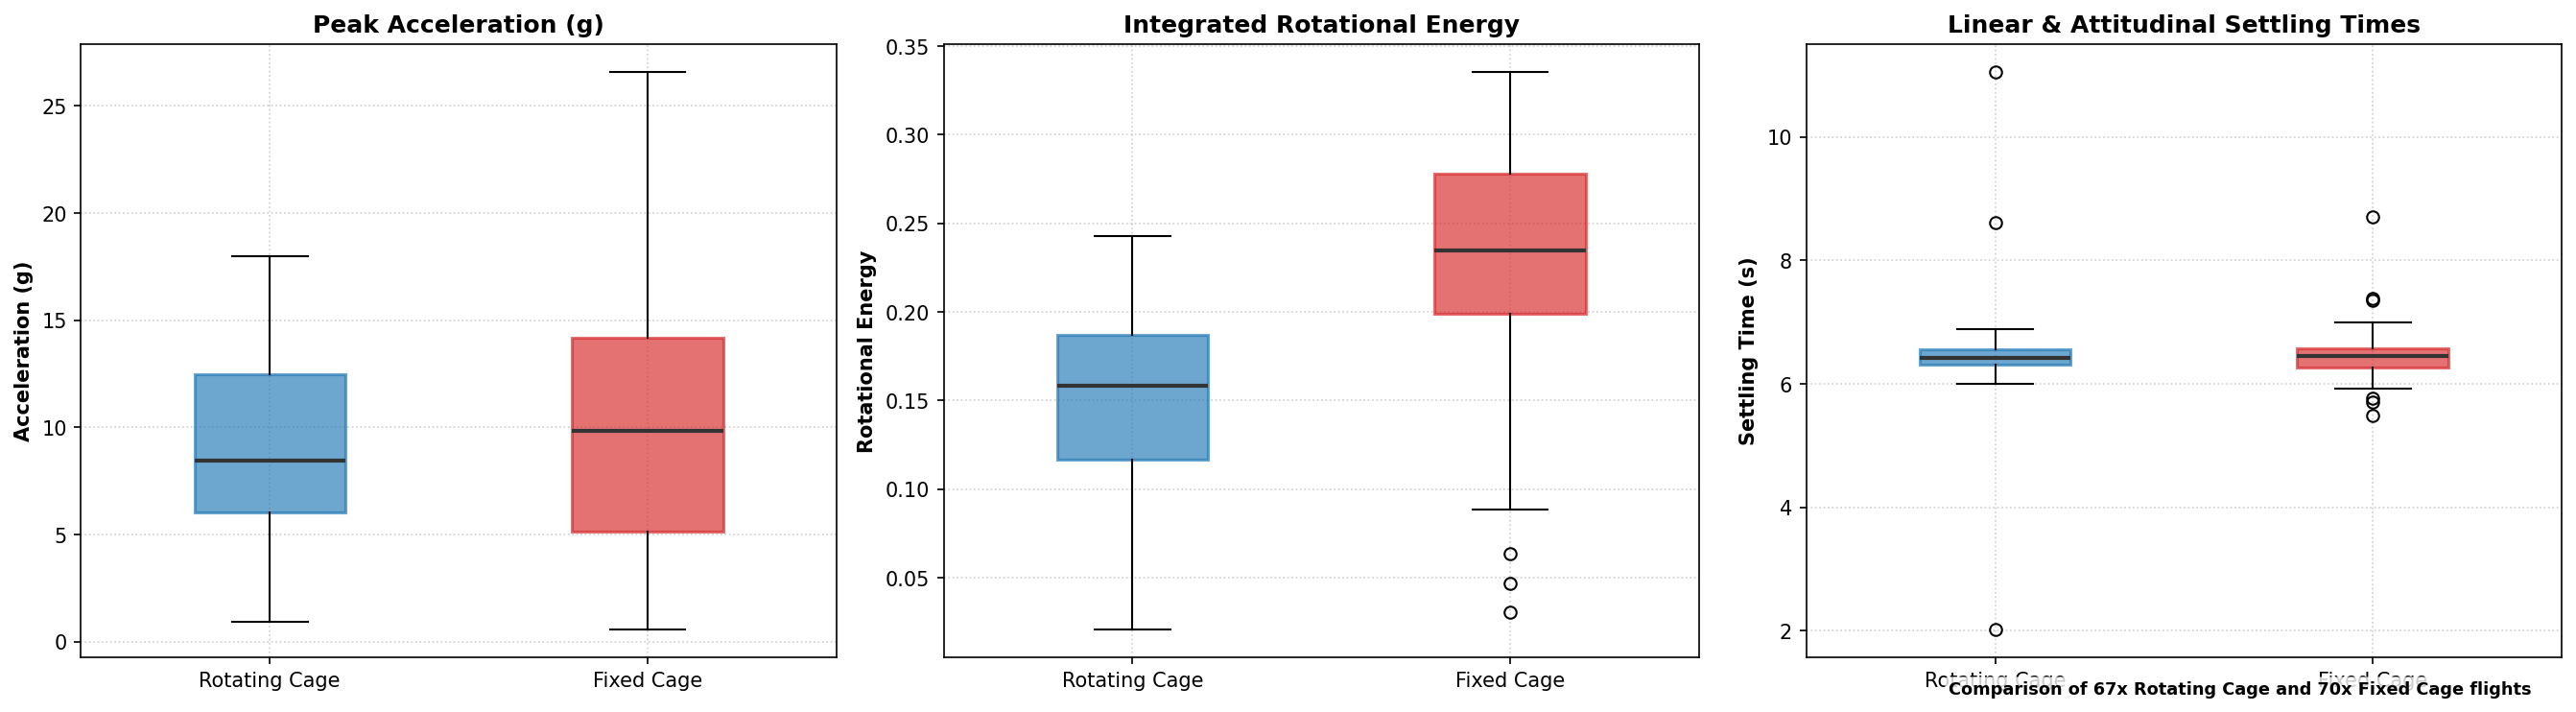

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)

box_groups = ['Rotating Cage', 'Fixed Cage']

# Plot 12a: Peak Acceleration
box_data_accel = [df_impacts[df_impacts['condition'] == name]['imu_peak_accel'].dropna() for name in box_groups]
bp0 = axes[0].boxplot(box_data_accel, labels=box_groups, patch_artist=True, widths=0.4)
axes[0].set_title('Peak Acceleration (g)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Acceleration (g)', fontsize=10, fontweight='bold')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 12b: Integrated Shock Impulse (Rotational Energy)
box_data_energy = [df_impacts[df_impacts['condition'] == name]['imu_gyro_energy'].dropna() for name in box_groups]
bp1 = axes[1].boxplot(box_data_energy, labels=box_groups, patch_artist=True, widths=0.4)
axes[1].set_title('Integrated Rotational Energy', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rotational Energy', fontsize=10, fontweight='bold')
axes[1].grid(True, linestyle=':', alpha=0.6)

# Plot 12c: Attitudinal Settling Times
box_data_settling = [df_impacts[df_impacts['condition'] == name]['imu_gyro_settling'].dropna() for name in box_groups]
bp2 = axes[2].boxplot(box_data_settling, labels=box_groups, patch_artist=True, widths=0.4)
axes[2].set_title('Linear & Attitudinal Settling Times', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Settling Time (s)', fontsize=10, fontweight='bold')
axes[2].grid(True, linestyle=':', alpha=0.6)

# Colors and Styling
colors = ['#1F77B4', '#D62728']
for bp in [bp0, bp1, bp2]:
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
        patch.set_edgecolor(color)
        patch.set_linewidth(1.5)
    for median in bp['medians']:
        median.set(color='#333333', linewidth=2.0)

# Add dynamic data origin label
n_rot_total = len(box_data_accel[0])
n_fix_total = len(box_data_accel[1])
fig.text(0.98, 0.02, f"Comparison of {n_rot_total}x Rotating Cage and {n_fix_total}x Fixed Cage flights",
         ha='right', va='bottom', fontsize=8.5, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
os.makedirs('graphics', exist_ok=True)
plt.savefig('graphics/recovery_area_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


---

## 🌟 Advanced Thesis Highlights

These final plots encapsulate the core thesis conclusions by mapping multidimensional metrics.

/tmp/ipykernel_80547/1457397037.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


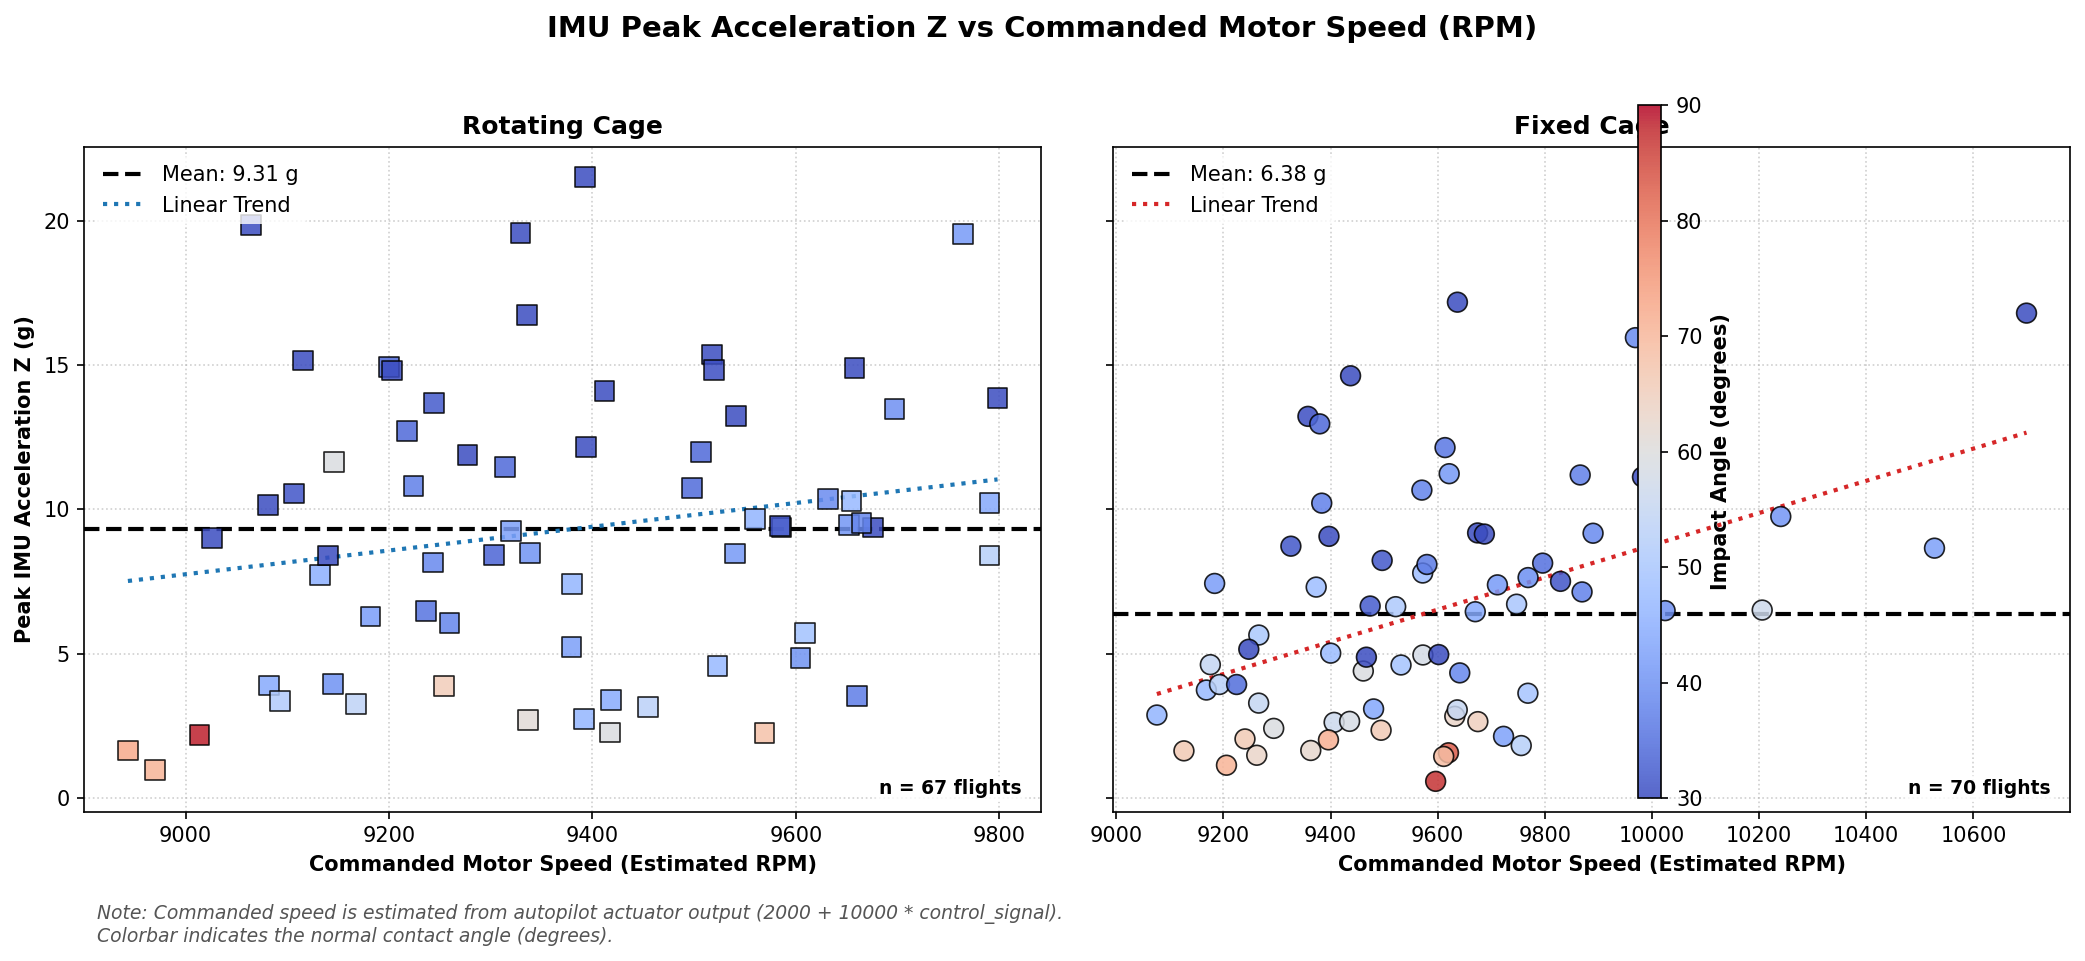

In [15]:
# Plot A: IMU Z vs Commanded Motor Speed (RPM)
import matplotlib.pyplot as plt
import numpy as np
import os
from dev_logs.analysis.database.db_manager import get_database_df

df_all = get_database_df()
df_impacts = df_all.query("impact_detected == 1").copy()

# Compute RPM estimation
df_impacts['estimated_rpm'] = 2000 + 10000 * df_impacts['motor_max_after']

# Clean missing parameters
plot_data = df_impacts.dropna(subset=['estimated_rpm', 'imu_peak_accel_z', 'impact_angle'])

# Subset by cage type
df_rot = plot_data.query("condition == 'Rotating Cage'")
df_fix = plot_data.query("condition == 'Fixed Cage'")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=150, sharey=True)

# Colormap normalization based on impact angle (typically 30° to 90°)
norm = plt.Normalize(30, 90)
cmap = plt.cm.coolwarm

# Plot Rotating Cage (Squares)
sc_rot = ax1.scatter(
    df_rot['estimated_rpm'],
    df_rot['imu_peak_accel_z'],
    c=df_rot['impact_angle'],
    cmap=cmap,
    norm=norm,
    marker='s',
    s=90,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.8,
    zorder=3
)
mean_rot = df_rot['imu_peak_accel_z'].mean()
ax1.axhline(mean_rot, color='black', linestyle='--', linewidth=2, label=f'Mean: {mean_rot:.2f} g')
if len(df_rot) > 1:
    z_rot = np.polyfit(df_rot['estimated_rpm'], df_rot['imu_peak_accel_z'], 1)
    p_rot = np.poly1d(z_rot)
    xp_rot = np.linspace(df_rot['estimated_rpm'].min(), df_rot['estimated_rpm'].max(), 100)
    ax1.plot(xp_rot, p_rot(xp_rot), color='#1F77B4', linestyle=':', linewidth=2, label='Linear Trend')

ax1.set_title('Rotating Cage', fontsize=12, fontweight='bold')
ax1.set_xlabel('Commanded Motor Speed (Estimated RPM)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Peak IMU Acceleration Z (g)', fontsize=10, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
ax1.text(0.98, 0.02, f"n = {len(df_rot)} flights",
        transform=ax1.transAxes, ha='right', va='bottom', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# Plot Fixed Cage (Circles)
sc_fix = ax2.scatter(
    df_fix['estimated_rpm'],
    df_fix['imu_peak_accel_z'],
    c=df_fix['impact_angle'],
    cmap=cmap,
    norm=norm,
    marker='o',
    s=90,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.8,
    zorder=3
)
mean_fix = df_fix['imu_peak_accel_z'].mean()
ax2.axhline(mean_fix, color='black', linestyle='--', linewidth=2, label=f'Mean: {mean_fix:.2f} g')
if len(df_fix) > 1:
    z_fix = np.polyfit(df_fix['estimated_rpm'], df_fix['imu_peak_accel_z'], 1)
    p_fix = np.poly1d(z_fix)
    xp_fix = np.linspace(df_fix['estimated_rpm'].min(), df_fix['estimated_rpm'].max(), 100)
    ax2.plot(xp_fix, p_fix(xp_fix), color='#D62728', linestyle=':', linewidth=2, label='Linear Trend')

ax2.set_title('Fixed Cage', fontsize=12, fontweight='bold')
ax2.set_xlabel('Commanded Motor Speed (Estimated RPM)', fontsize=10, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
ax2.text(0.98, 0.02, f"n = {len(df_fix)} flights",
        transform=ax2.transAxes, ha='right', va='bottom', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# Add Colorbar for Impact Angle
cbar = fig.colorbar(sc_fix, ax=[ax1, ax2], pad=0.02, aspect=30)
cbar.set_label('Impact Angle (degrees)', fontsize=10, fontweight='bold')

fig.suptitle('IMU Peak Acceleration Z vs Commanded Motor Speed (RPM)', fontsize=14, fontweight='bold', y=0.98)

# Add note explaining the estimated RPM
fig.text(0.05, -0.05, """Note: Commanded speed is estimated from autopilot actuator output (2000 + 10000 * control_signal).\nColorbar indicates the normal contact angle (degrees).""",
        fontsize=9, fontstyle='italic', color='#555555')

plt.tight_layout(rect=[0, 0, 1, 0.95])
os.makedirs('graphics', exist_ok=True)
plt.savefig('graphics/plot_A_imu_z_vs_rpm.png', dpi=300, bbox_inches='tight')
plt.show()



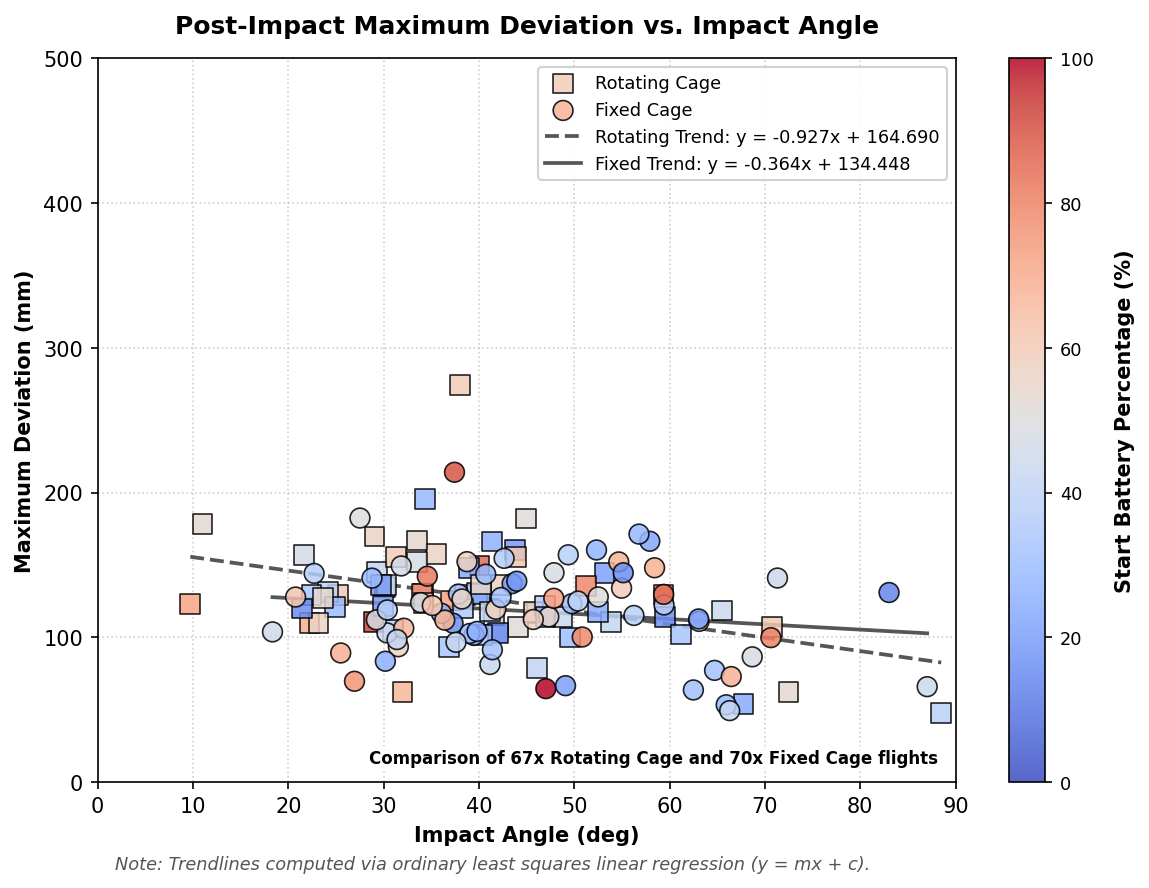

In [16]:
# Plot B: Impact Angle vs. Max Deviation
import matplotlib.pyplot as plt
import numpy as np
import os
from dev_logs.analysis.database.db_manager import get_database_df

df_all = get_database_df()
df_impacts = df_all.query("impact_detected == 1").copy()

# Clean missing parameters
plot_data = df_impacts.dropna(subset=['max_dev_after', 'battery_at_start', 'impact_angle'])

# Subset by cage type
df_rot = plot_data.query("condition == 'Rotating Cage'")
df_fix = plot_data.query("condition == 'Fixed Cage'")

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# Colormap normalization (continuous 0-100% battery)
norm = plt.Normalize(0, 100)
cmap = plt.cm.coolwarm

# Plot Rotating Cage (Squares)
sc_rot = ax.scatter(
    df_rot['impact_angle'],
    df_rot['max_dev_after'],
    c=df_rot['battery_at_start'],
    cmap=cmap,
    norm=norm,
    marker='s',
    s=90,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.8,
    zorder=3,
    label='Rotating Cage'
)

# Plot Fixed Cage (Circles)
sc_fix = ax.scatter(
    df_fix['impact_angle'],
    df_fix['max_dev_after'],
    c=df_fix['battery_at_start'],
    cmap=cmap,
    norm=norm,
    marker='o',
    s=90,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.8,
    zorder=3,
    label='Fixed Cage'
)

# Fit linear trendline for Rotating Cage (Dashed)
if len(df_rot) > 1:
    m_rot, c_rot = np.polyfit(df_rot['impact_angle'], df_rot['max_dev_after'], 1)
    x_rot = np.linspace(df_rot['impact_angle'].min(), df_rot['impact_angle'].max(), 100)
    ax.plot(x_rot, m_rot * x_rot + c_rot, color='#444444', linestyle='--', linewidth=1.8, alpha=0.9,
            label=f'Rotating Trend: y = {m_rot:.3f}x + {c_rot:.3f}')

# Fit linear trendline for Fixed Cage (Solid)
if len(df_fix) > 1:
    m_fix, c_fix = np.polyfit(df_fix['impact_angle'], df_fix['max_dev_after'], 1)
    x_fix = np.linspace(df_fix['impact_angle'].min(), df_fix['impact_angle'].max(), 100)
    ax.plot(x_fix, m_fix * x_fix + c_fix, color='#444444', linestyle='-', linewidth=1.8, alpha=0.9,
            label=f'Fixed Trend: y = {m_fix:.3f}x + {c_fix:.3f}')

ax.set_title('Post-Impact Maximum Deviation vs. Impact Angle', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Impact Angle (deg)', fontsize=10, fontweight='bold')
ax.set_ylabel('Maximum Deviation (mm)', fontsize=10, fontweight='bold')
ax.set_xlim(0, 90)
ax.set_ylim(0, 500)
ax.grid(True, linestyle=':', alpha=0.6, zorder=0)

# Legend
ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)

# Colorbar for battery percentage at start
cbar = fig.colorbar(sc_rot, ax=ax)
cbar.set_label('Start Battery Percentage (%)', fontsize=10, fontweight='bold', labelpad=10)
cbar.ax.tick_params(labelsize=8.5)

# Explanatory subtitle/footnote for regression lines
ax.text(0.02, -0.12, "Note: Trendlines computed via ordinary least squares linear regression (y = mx + c).",
        transform=ax.transAxes, fontsize=8.5, fontstyle='italic', color='#555555')

# Add dynamic data origin label
n_rot_total = df_rot.shape[0]
n_fix_total = df_fix.shape[0]
ax.text(0.98, 0.02, f"Comparison of {n_rot_total}x Rotating Cage and {n_fix_total}x Fixed Cage flights",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
os.makedirs('graphics', exist_ok=True)
plt.savefig('graphics/plot_14_angle_vs_deviation.png', dpi=300, bbox_inches='tight')
plt.show()


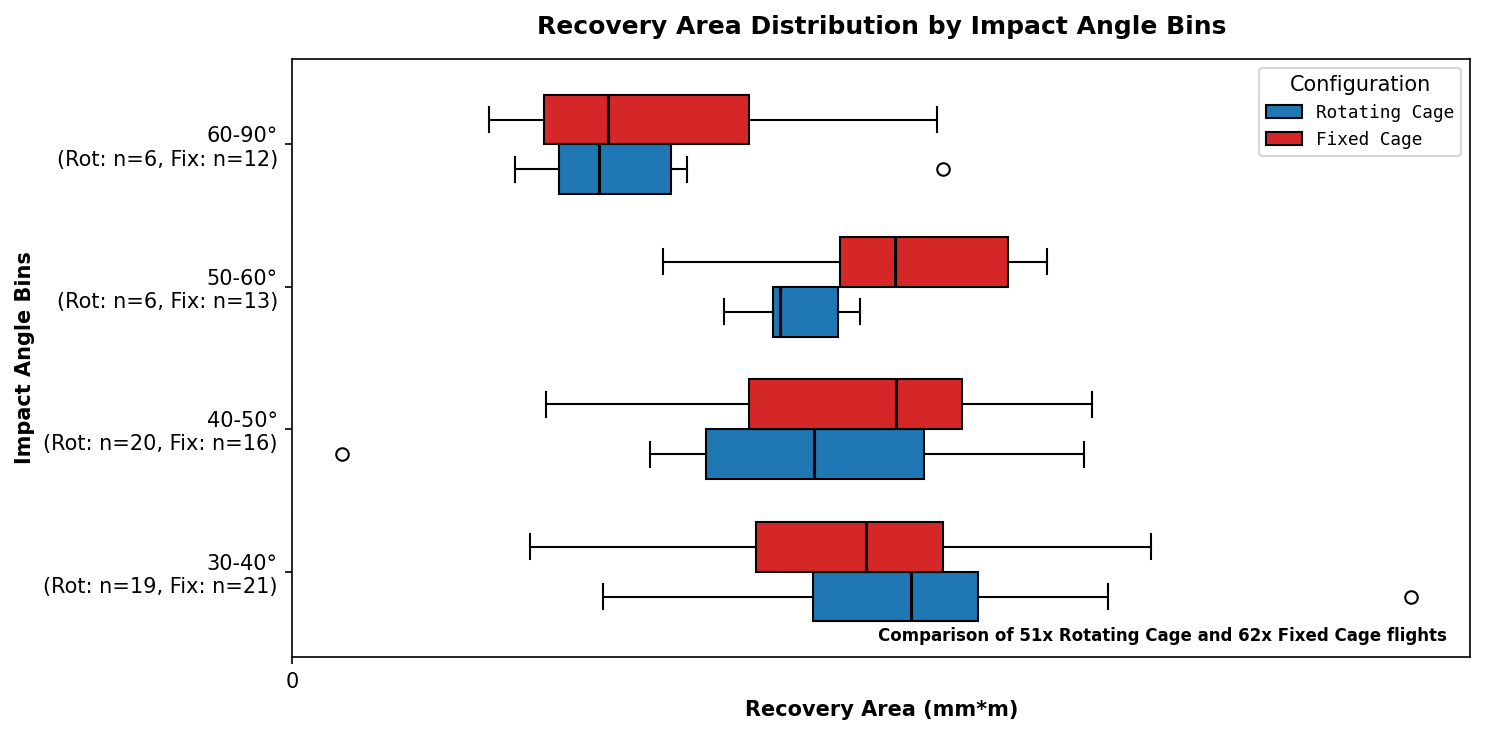

In [17]:
# Plot C: Recovery Area Distribution
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from dev_logs.analysis.database.db_manager import get_database_df
import pandas as pd

df_all = get_database_df()
df_impacts = df_all.query("impact_detected == 1").copy()

# Bins split by collapsed bins (30-40, 40-50, 50-60, 60-90)
bins = [30, 40, 50, 60, 90]
labels_boxplot = ['30-40°', '40-50°', '50-60°', '60-90°']

df_impacts_valid = df_impacts.dropna(subset=['impact_angle']).copy()
df_impacts_valid['angle_bin'] = pd.cut(df_impacts_valid['impact_angle'], bins=bins, labels=labels_boxplot, right=False)
df_impacts_valid.loc[df_impacts_valid['impact_angle'] == 90, 'angle_bin'] = '60-90°'

df_plot_c = df_impacts_valid.dropna(subset=['recovery_area', 'angle_bin']).copy()
df_plot_c['recovery_area_mmm'] = df_plot_c['recovery_area']

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

# Extract data for boxplots
labels_list = ['30-40°', '40-50°', '50-60°', '60-90°']
box_data_rot = []
box_data_fix = []

for label in labels_list:
    subset = df_plot_c[df_plot_c['angle_bin'] == label]
    rot_vals = subset[subset['condition'] == 'Rotating Cage']['recovery_area_mmm'].values
    fix_vals = subset[subset['condition'] == 'Fixed Cage']['recovery_area_mmm'].values
    box_data_rot.append(rot_vals if len(rot_vals) > 0 else np.array([]))
    box_data_fix.append(fix_vals if len(fix_vals) > 0 else np.array([]))

# Create positions
positions = np.arange(len(labels_list))
width = 0.35

# Boxplot without seaborn
bp_rot = ax.boxplot(box_data_rot, positions=positions - width/2, vert=False, widths=width, patch_artist=True,
                    boxprops=dict(facecolor='#1F77B4', color='black'),
                    medianprops=dict(color='black', linewidth=1.5))
bp_fix = ax.boxplot(box_data_fix, positions=positions + width/2, vert=False, widths=width, patch_artist=True,
                    boxprops=dict(facecolor='#D62728', color='black'),
                    medianprops=dict(color='black', linewidth=1.5))

ax.set_yticks(positions)
yticklabels = []
for i, label in enumerate(labels_list):
    n_rot_bin = len(box_data_rot[i])
    n_fix_bin = len(box_data_fix[i])
    yticklabels.append(f"{label}\n(Rot: n={n_rot_bin}, Fix: n={n_fix_bin})")
ax.set_yticklabels(yticklabels)

ax.set_title('Recovery Area Distribution by Impact Angle Bins', fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Impact Angle Bins', fontsize=10, fontweight='bold')
ax.set_xlabel('Recovery Area (mm*m)', fontsize=10, fontweight='bold')

# Standardized limits and ticks
ax.set_xlim(0, 250)
ax.set_xticks(np.arange(0, 251, 500))
ax.set_ylim(-0.6, len(labels_list) - 0.4)
ax.grid(True, linestyle=':', alpha=0.6, axis='x')

# Custom legend
legend_elements = [
    Patch(facecolor='#1F77B4', edgecolor='black', label='Rotating Cage'),
    Patch(facecolor='#D62728', edgecolor='black', label='Fixed Cage')
]
ax.legend(handles=legend_elements, title='Configuration', loc='upper right', prop={'family': 'monospace', 'size': 8.5})

# Add dynamic data origin label
n_rot_total = df_plot_c[df_plot_c['condition'] == 'Rotating Cage'].shape[0]
n_fix_total = df_plot_c[df_plot_c['condition'] == 'Fixed Cage'].shape[0]
ax.text(0.98, 0.02, f"Comparison of {n_rot_total}x Rotating Cage and {n_fix_total}x Fixed Cage flights",
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
os.makedirs('graphics', exist_ok=True)
plt.savefig('graphics/plot_15_recovery_distribution.png', dpi=300)
plt.show()


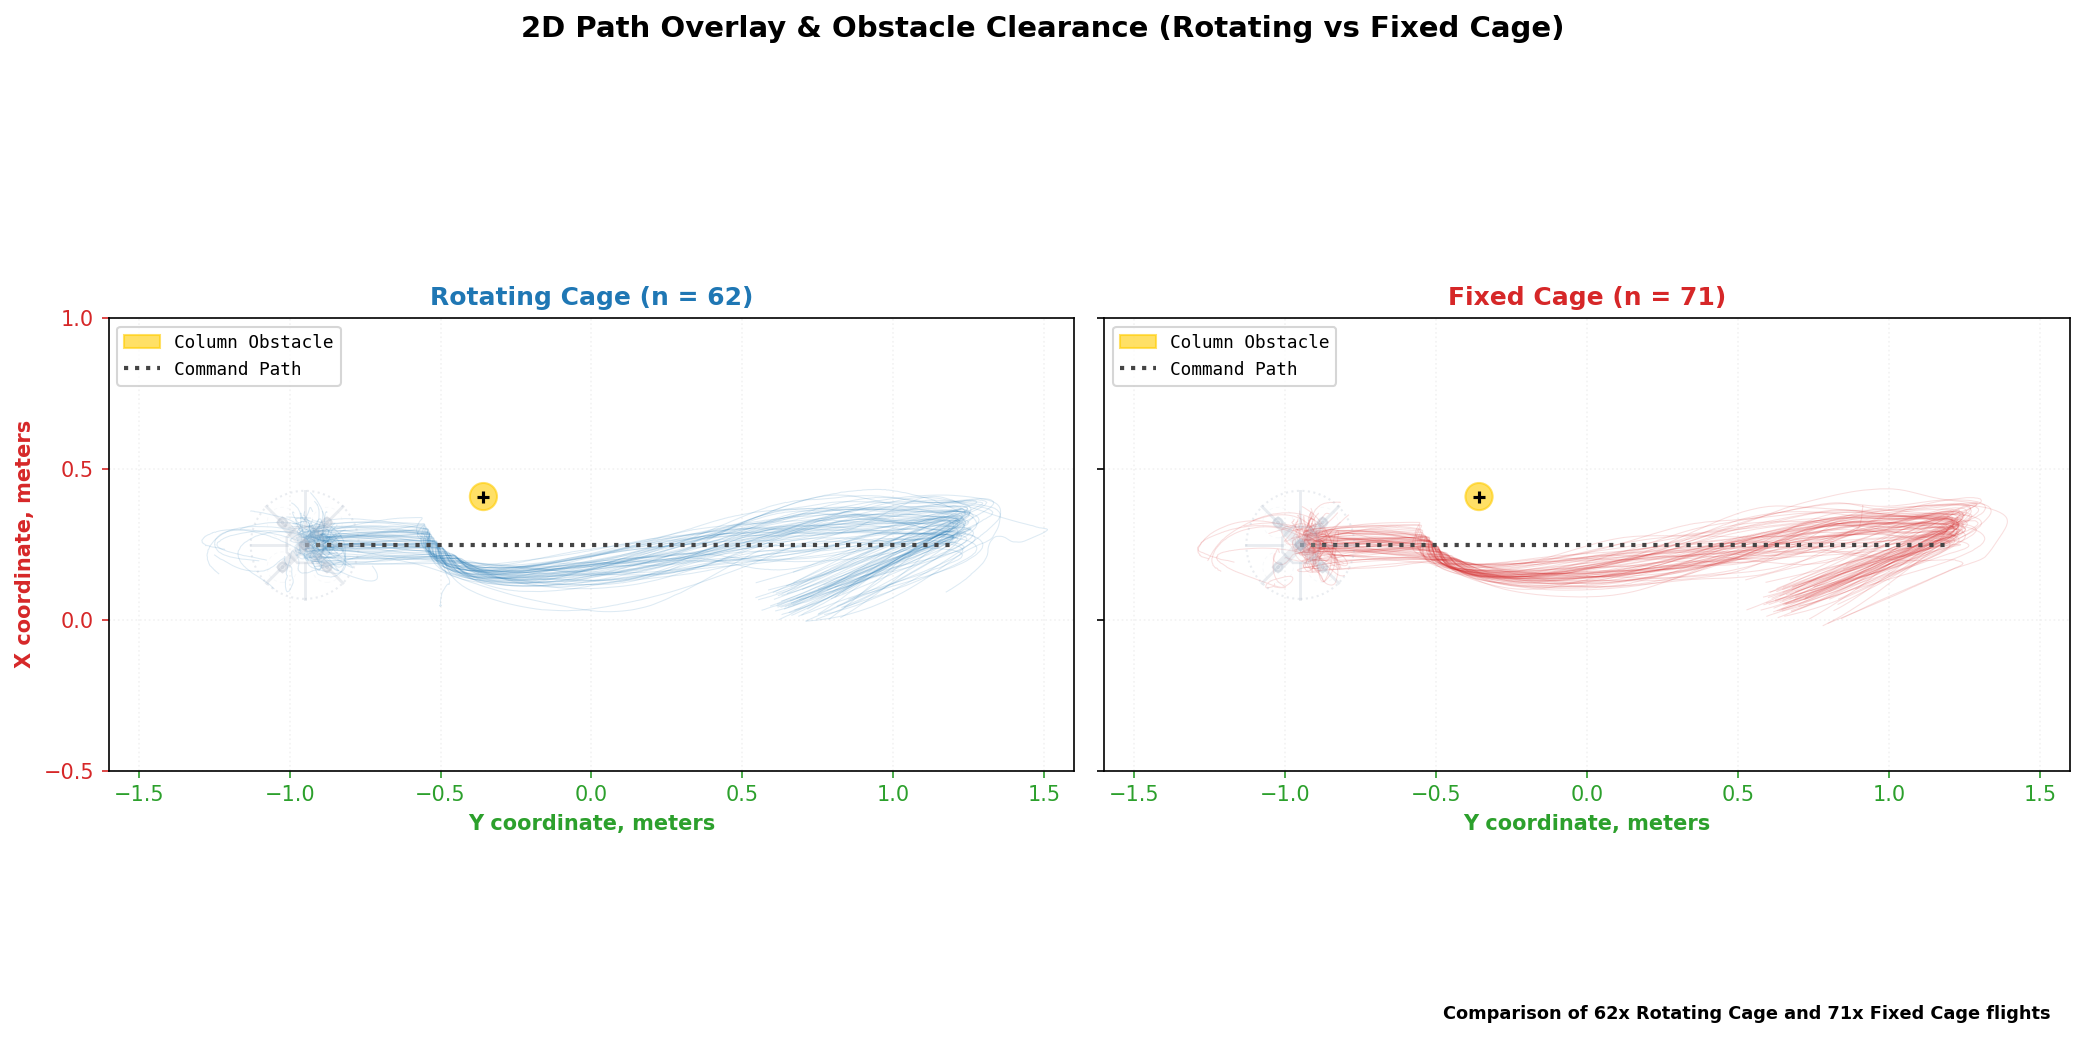

In [18]:
# Plot D: 2D Path Overlay
import pickle
import numpy as np
import matplotlib.pyplot as plt
from dev_logs.analysis.kinematics.kin_plot_trajectory import rotate_coords
from graphics import draw_vector_drone
import os

# Load cached MoCap trajectory data
cache_path = 'database/trajectory_cache.pkl'
with open(cache_path, 'rb') as f:
    cache_flights = pickle.load(f)

# Subset trajectories by cage type
flights_rot = [f for f in cache_flights if f['condition'] == 'Rotating Cage']
flights_fix = [f for f in cache_flights if f['condition'] == 'Fixed Cage']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=True, dpi=150)

# Obstacle definition
column_x, column_y = 0.408, 0.358
column_radius = 0.045
rot_col_x, rot_col_y = rotate_coords(column_x, column_y)

# Command waypoints (45 deg lane)
x_lane = 0.248
wps = np.array([[x_lane, 0.950], [x_lane, -1.200]])
rot_wps_x, rot_wps_y = rotate_coords(wps[:, 0], wps[:, 1])

# Plot Rotating Cage trajectories on Left Subplot
for flight in flights_rot:
    x_new, y_new = rotate_coords(flight['x'], flight['y'])
    ax1.plot(x_new, y_new, color='#1F77B4', alpha=0.15, linewidth=0.5, zorder=2)

# Plot Fixed Cage trajectories on Right Subplot
for flight in flights_fix:
    x_new, y_new = rotate_coords(flight['x'], flight['y'])
    ax2.plot(x_new, y_new, color='#D62728', alpha=0.15, linewidth=0.5, zorder=2)

# Configure both subplots
for ax, flights_list, name, color in [(ax1, flights_rot, 'Rotating Cage', '#1F77B4'), 
                                      (ax2, flights_fix, 'Fixed Cage', '#D62728')]:
    # Obstacle
    column_circle = plt.Circle((rot_col_x, rot_col_y), column_radius, color='#FFCC00', alpha=0.6, label='Column Obstacle', zorder=4)
    ax.add_patch(column_circle)
    ax.scatter(rot_col_x, rot_col_y, color='black', marker='+', zorder=5)
    
    # Commanded Path
    ax.plot(rot_wps_x, rot_wps_y, color='#444444', linestyle=':', linewidth=2, zorder=5, label='Command Path')
    draw_vector_drone(ax, rot_wps_x[0], rot_wps_y[0], 0.179, rotation_deg=0, color_mode='gray')
    
    # Limits and ticks from SSoT
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-0.5, 1.0)
    ax.set_xticks(np.arange(-1.5, 1.6, 0.5))
    ax.set_yticks(np.arange(-0.5, 1.1, 0.5))
    ax.set_xlabel('Y coordinate, meters', color='#2CA02C', fontweight='bold')
    ax.grid(True, color='#EAEAEA', linestyle=':', alpha=0.6)
    
    # Title with dynamic N-count
    ax.set_title(f'{name} (n = {len(flights_list)})', fontsize=12, fontweight='bold', color=color)
    ax.legend(loc='upper left', prop={'family': 'monospace', 'size': 8.5})

# Label Y axis only on Left Subplot
ax1.set_ylabel('X coordinate, meters', color='#D62728', fontweight='bold')
ax1.tick_params(axis='y', colors='#D62728')
for ax in (ax1, ax2):
    ax.tick_params(axis='x', colors='#2CA02C')

fig.suptitle('2D Path Overlay & Obstacle Clearance (Rotating vs Fixed Cage)', fontsize=14, fontweight='bold', y=0.98)

# Add dynamic data origin label in the bottom-right corner of the whole figure
n_rot_total = len(flights_rot)
n_fix_total = len(flights_fix)
fig.text(0.98, 0.02, f"Comparison of {n_rot_total}x Rotating Cage and {n_fix_total}x Fixed Cage flights",
         ha='right', va='bottom', fontsize=8.5, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
os.makedirs('graphics', exist_ok=True)
plt.savefig('graphics/plot_16_path_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_80547/1011951376.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp4 = ax2.boxplot(box_data_vib, labels=['Rotating Cage', 'Fixed Cage'], patch_artist=True, widths=0.4)


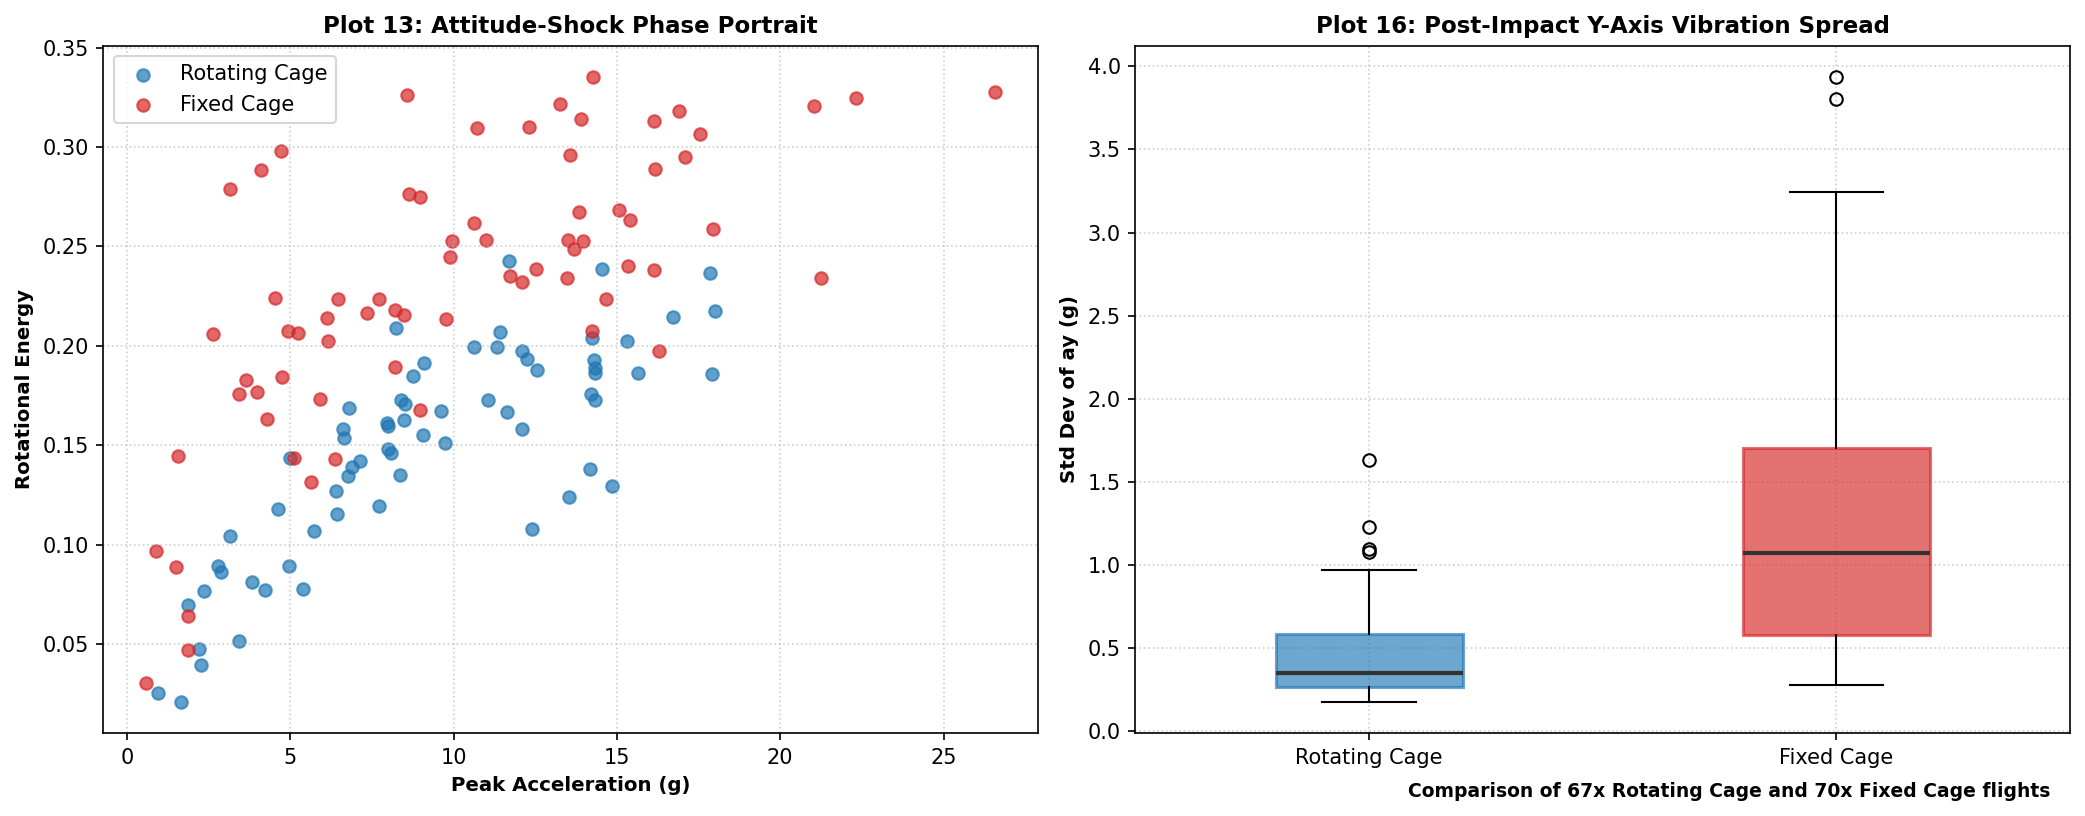

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sqlite3
from dev_logs.analysis.database.db_manager import get_battery_efficiency_df

colors_list = ['#1F77B4', '#D62728']

fig = plt.figure(figsize=(14, 5.5), dpi=150)

# Plot 13: Attitude-Shock Phase Portrait
ax1 = fig.add_subplot(121)
for cond, color in zip(['Rotating Cage', 'Fixed Cage'], colors_list):
    sub = df_impacts[df_impacts['condition'] == cond]
    ax1.scatter(sub['imu_peak_accel'], sub['imu_gyro_energy'], label=cond, color=color, alpha=0.7)
ax1.set_title('Plot 13: Attitude-Shock Phase Portrait', fontsize=11, fontweight='bold')
ax1.set_xlabel('Peak Acceleration (g)', fontsize=9.5, fontweight='bold')
ax1.set_ylabel('Rotational Energy', fontsize=9.5, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# Plot 16: Post-Impact Raw IMU Oscillation Spread
ax2 = fig.add_subplot(122)
box_data_vib = [df_impacts[df_impacts['condition'] == name]['imu_vib_ay'].dropna() for name in ['Rotating Cage', 'Fixed Cage']]
bp4 = ax2.boxplot(box_data_vib, labels=['Rotating Cage', 'Fixed Cage'], patch_artist=True, widths=0.4)
for patch, color in zip(bp4['boxes'], colors_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
    patch.set_edgecolor(color)
    patch.set_linewidth(1.5)
for median in bp4['medians']:
    median.set(color='#333333', linewidth=2.0)
ax2.set_title('Plot 16: Post-Impact Y-Axis Vibration Spread', fontsize=11, fontweight='bold')
ax2.set_ylabel('Std Dev of ay (g)', fontsize=9.5, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

# Add dynamic data origin label for the whole figure
n_rot_total = df_impacts[df_impacts['condition'] == 'Rotating Cage'].shape[0]
n_fix_total = df_impacts[df_impacts['condition'] == 'Fixed Cage'].shape[0]
fig.text(0.98, 0.02, f"Comparison of {n_rot_total}x Rotating Cage and {n_fix_total}x Fixed Cage flights",
         ha='right', va='bottom', fontsize=9, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
os.makedirs('graphics', exist_ok=True)
plt.savefig('graphics/advanced_thesis_highlights.png', dpi=300)
plt.show()


### 📈 3. STATISTICAL AGGREGATE PERFORMANCE ANALYSIS
This section queries the SQLite database to generate comparative boxplots, scatterplots, and heatmaps across all passes, forming the primary quantitative findings of the thesis.

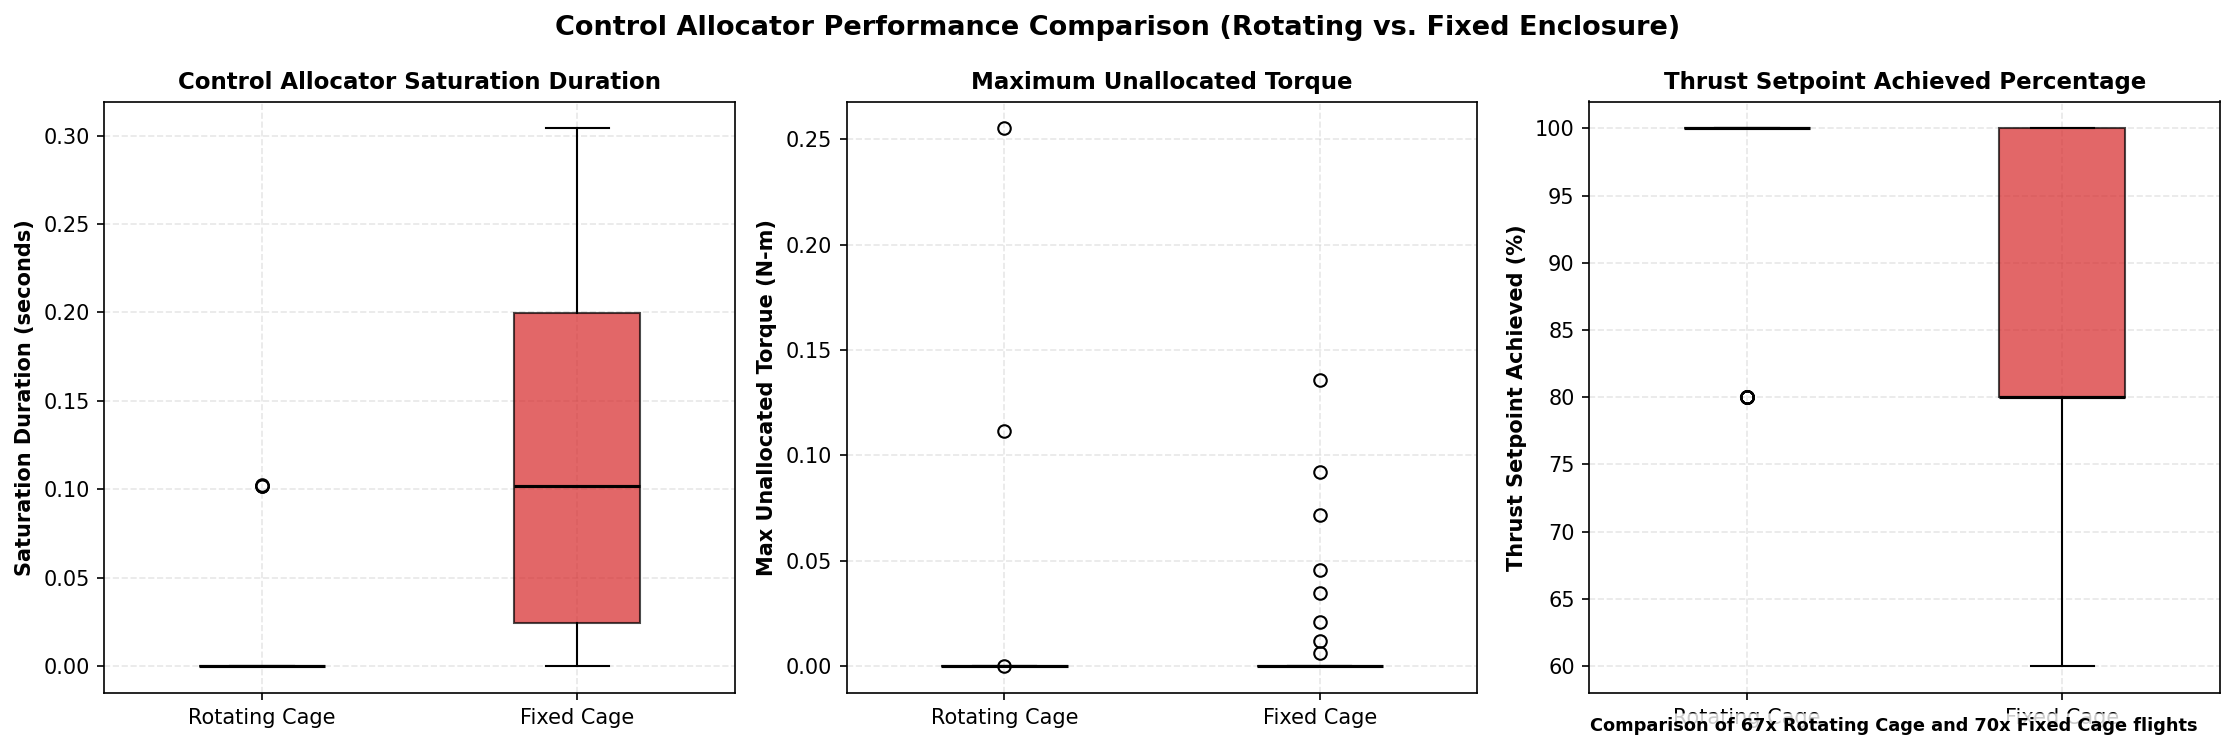

In [20]:
import sys, os
project_root = os.path.abspath(os.path.join(os.path.abspath(''), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Plot 17: Control Allocator Saturation Comparison
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from dev_logs.analysis.database.db_manager import get_database_df

# Load the flights database
df_all = get_database_df()
df_impacts = df_all.query("impact_detected == 1").copy()
df_plot = df_impacts.dropna(subset=['allocator_saturation_duration_sec', 'max_unallocated_torque', 'thrust_setpoint_achieved_pct'])

# Define clean color palette matching dashboard SSoT
color_rot = '#1F77B4' # Sleek Blue
color_fix = '#D62728' # Vibrant Red
colors = [color_rot, color_fix]

df_rot = df_plot[df_plot['condition'] == 'Rotating Cage']
df_fix = df_plot[df_plot['condition'] == 'Fixed Cage']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150)

# Panel A: Saturation Duration
box_data_sat = [df_rot['allocator_saturation_duration_sec'].dropna(), df_fix['allocator_saturation_duration_sec'].dropna()]
bp_sat = axes[0].boxplot(box_data_sat, tick_labels=['Rotating Cage', 'Fixed Cage'], patch_artist=True, widths=0.4,
                         medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp_sat['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('Saturation Duration (seconds)', fontsize=10, fontweight='bold')
axes[0].set_title('Control Allocator Saturation Duration', fontsize=11, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.3)

# Panel B: Max Unallocated Torque
box_data_tq = [df_rot['max_unallocated_torque'].dropna(), df_fix['max_unallocated_torque'].dropna()]
bp_tq = axes[1].boxplot(box_data_tq, tick_labels=['Rotating Cage', 'Fixed Cage'], patch_artist=True, widths=0.4,
                        medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp_tq['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Max Unallocated Torque (N-m)', fontsize=10, fontweight='bold')
axes[1].set_title('Maximum Unallocated Torque', fontsize=11, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.3)

# Panel C: Thrust Setpoint Achieved Pct
box_data_th = [df_rot['thrust_setpoint_achieved_pct'].dropna(), df_fix['thrust_setpoint_achieved_pct'].dropna()]
bp_th = axes[2].boxplot(box_data_th, tick_labels=['Rotating Cage', 'Fixed Cage'], patch_artist=True, widths=0.4,
                        medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp_th['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_ylabel('Thrust Setpoint Achieved (%)', fontsize=10, fontweight='bold')
axes[2].set_title('Thrust Setpoint Achieved Percentage', fontsize=11, fontweight='bold')
axes[2].grid(True, linestyle='--', alpha=0.3)

fig.suptitle('Control Allocator Performance Comparison (Rotating vs. Fixed Enclosure)', fontsize=13, fontweight='bold', y=0.98)
fig.text(0.98, 0.02, f"Comparison of {len(df_rot)}x Rotating Cage and {len(df_fix)}x Fixed Cage flights",
         ha='right', va='bottom', fontsize=8.5, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
os.makedirs('graphics', exist_ok=True)
plt.savefig('graphics/plot_17_allocator_saturation_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

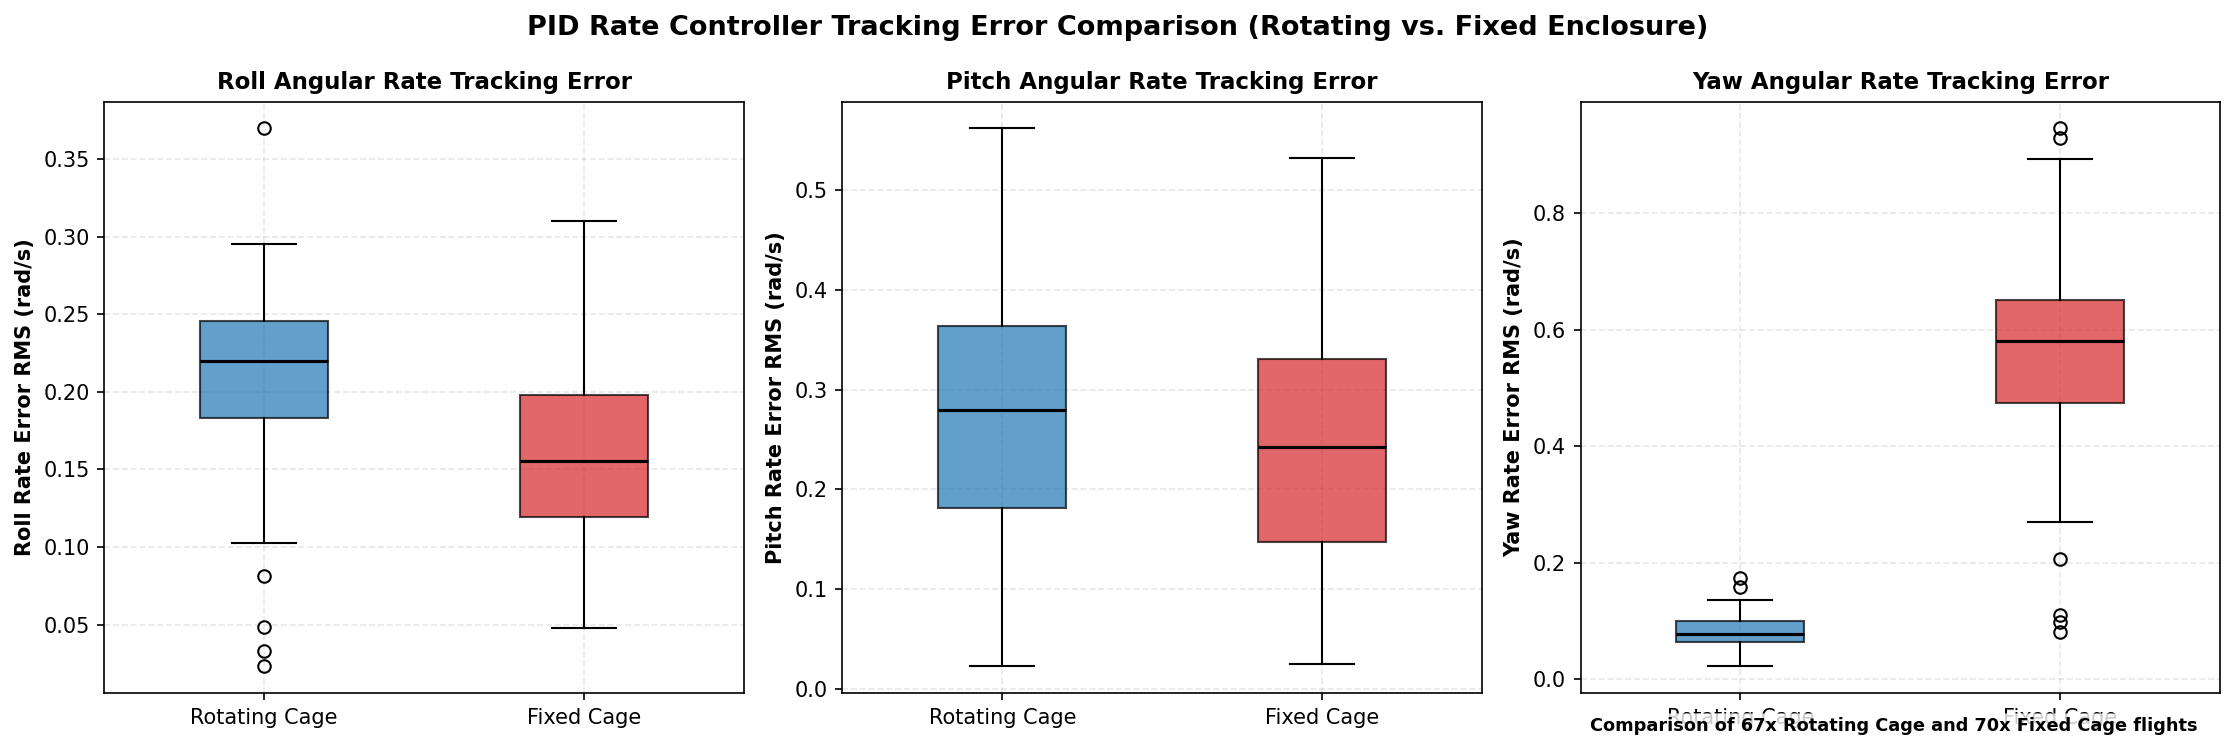

In [21]:
import sys, os
project_root = os.path.abspath(os.path.join(os.path.abspath(''), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Plot 18: PID Tracking Error (RMS) Comparison
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5), dpi=150)

# Panel A: Roll Rate Error RMS
box_data_roll = [df_rot['roll_rate_error_rms'].dropna(), df_fix['roll_rate_error_rms'].dropna()]
bp_roll = axes2[0].boxplot(box_data_roll, tick_labels=['Rotating Cage', 'Fixed Cage'], patch_artist=True, widths=0.4,
                           medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp_roll['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes2[0].set_ylabel('Roll Rate Error RMS (rad/s)', fontsize=10, fontweight='bold')
axes2[0].set_title('Roll Angular Rate Tracking Error', fontsize=11, fontweight='bold')
axes2[0].grid(True, linestyle='--', alpha=0.3)

# Panel B: Pitch Rate Error RMS
box_data_pitch = [df_rot['pitch_rate_error_rms'].dropna(), df_fix['pitch_rate_error_rms'].dropna()]
bp_pitch = axes2[1].boxplot(box_data_pitch, tick_labels=['Rotating Cage', 'Fixed Cage'], patch_artist=True, widths=0.4,
                            medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp_pitch['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes2[1].set_ylabel('Pitch Rate Error RMS (rad/s)', fontsize=10, fontweight='bold')
axes2[1].set_title('Pitch Angular Rate Tracking Error', fontsize=11, fontweight='bold')
axes2[1].grid(True, linestyle='--', alpha=0.3)

# Panel C: Yaw Rate Error RMS
box_data_yaw = [df_rot['yaw_rate_error_rms'].dropna(), df_fix['yaw_rate_error_rms'].dropna()]
bp_yaw = axes2[2].boxplot(box_data_yaw, tick_labels=['Rotating Cage', 'Fixed Cage'], patch_artist=True, widths=0.4,
                          medianprops=dict(color='black', linewidth=1.5))
for patch, color in zip(bp_yaw['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes2[2].set_ylabel('Yaw Rate Error RMS (rad/s)', fontsize=10, fontweight='bold')
axes2[2].set_title('Yaw Angular Rate Tracking Error', fontsize=11, fontweight='bold')
axes2[2].grid(True, linestyle='--', alpha=0.3)

fig2.suptitle('PID Rate Controller Tracking Error Comparison (Rotating vs. Fixed Enclosure)', fontsize=13, fontweight='bold', y=0.98)
fig2.text(0.98, 0.02, f"Comparison of {len(df_rot)}x Rotating Cage and {len(df_fix)}x Fixed Cage flights",
          ha='right', va='bottom', fontsize=8.5, fontweight='bold',
          bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.savefig('graphics/plot_18_pid_tracking_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---
### 📉 4. AGGREGATED IMU COLLISION DYNAMICS
This section displays the time-normalized IMU collision dynamics traces for all impact flights, effectively superimposing physical acceleration and gyro reactions.


Loaded 137 IMU traces.
Aggregated IMU plot saved to /home/dorten/MasterThesisDrone/dev_logs/analysis/graphics/plot_aggregated_imu_dynamics.png


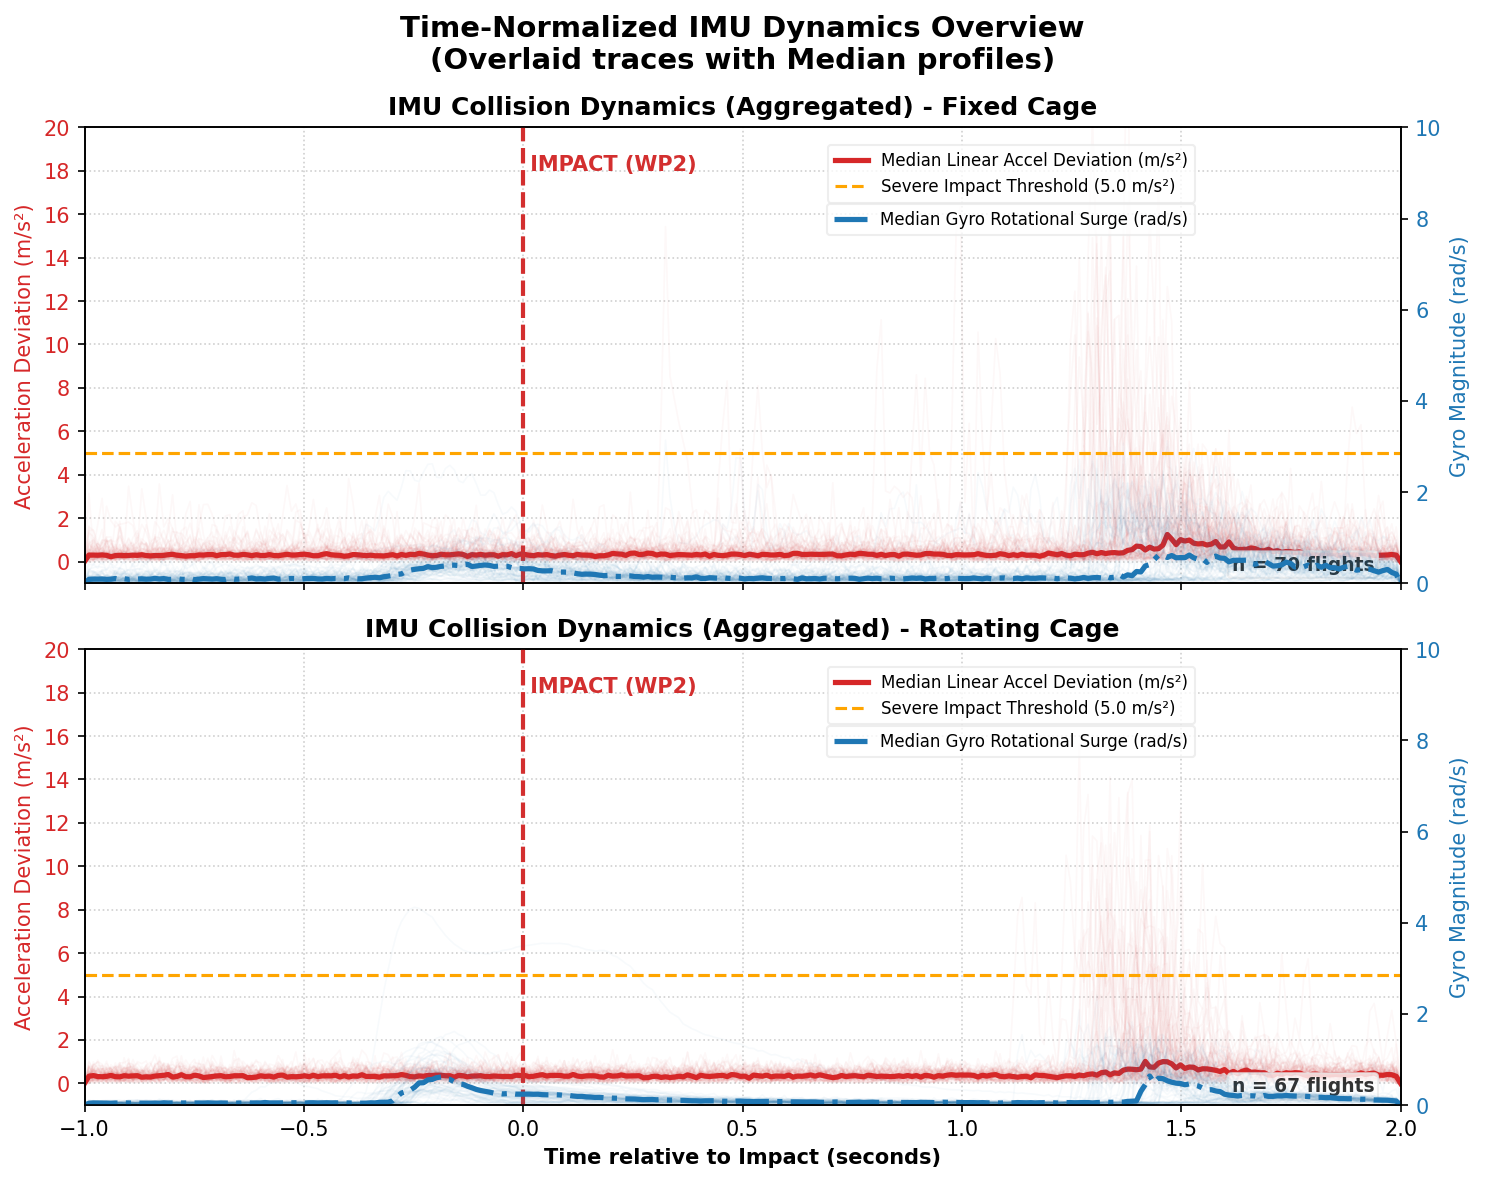

In [22]:
import sys, os
project_root = os.path.abspath(os.path.join(os.path.abspath(''), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Plot 19: Aggregated IMU Collision Dynamics
from dev_logs.analysis.graphics.plot_aggregated_imu_dynamics import generate_aggregated_imu_plot
generate_aggregated_imu_plot()


### 🏆 Master Comparison Metrics Table

| Category | Metric | Rotating Cage (Mean) | Fixed Cage (Mean) | Δ Improvement (%) |
|----------|--------|----------------------|-------------------|-------------------|
| **Kinematics** | Peak Acceleration Z (g) | 7.766 | 5.327 | -45.8% |
| **Motors** | Max Actuator Output (%) | 72.222 | 74.413 | +2.9% |
| **Motors** | Estimated RPM | 9222.166 | 9441.252 | +2.3% |
| **Tracking** | Recovery Path Spread (m²) | 111.525 | 108.195 | -3.1% |



### 🏗️ Structural Dynamics Boxplots
![Structural Dynamics Boxplots](graphics/structural_dynamics_boxplots.png)

In [24]:
# 🧮 Master Comparison Metrics Table
import sqlite3
import numpy as np

def compute_metrics():
    conn = sqlite3.connect('dev_logs/analysis/experiments_summary.db')
    cursor = conn.cursor()
    
    # Query all columns for Rotating Cage and Fixed Cage flights with detected impact
    query = """
    SELECT 
        condition,
        AVG(imu_peak_accel_z),
        AVG(max_actuator_output),
        AVG(motor_max_after),
        AVG(active_flight_time_sec),
        AVG(voltage_drop_rate_v_per_min),
        AVG(capacity_drain_rate_pct_per_min),
        AVG(recovery_area),
        AVG(path_spread_sdld),
        AVG(imu_ax_spread_impact),
        AVG(imu_ay_spread_impact),
        AVG(imu_az_spread_impact),
        AVG(imu_ax_spread_regular),
        AVG(imu_ay_spread_regular),
        AVG(imu_az_spread_regular),
        AVG(roll_rate_error_rms),
        AVG(pitch_rate_error_rms),
        AVG(yaw_rate_error_rms),
        AVG(allocator_saturation_duration_sec),
        AVG(max_unallocated_torque),
        AVG(thrust_setpoint_achieved_pct)
    FROM flights_summary
    WHERE impact_detected = 1
    GROUP BY condition
    """
    
    cursor.execute(query)
    rows = cursor.fetchall()
    conn.close()
    
    data = {}
    for r in rows:
        cond = r[0]
        data[cond] = {
            'peak_accel_z': r[1],
            'max_actuator': r[2] * 100 if r[2] else None,  # percentage
            'motor_max_after': r[3],
            'active_time': r[4],
            'voltage_drop': r[5],
            'capacity_drain': r[6],
            'recovery_area': (r[7] * 1000) if r[7] else None, # mm.m
            'path_sdld': (r[8] * 1000) if r[8] else None, # mm
            'ax_impact': r[9],
            'ay_impact': r[10],
            'az_impact': r[11],
            'ax_regular': r[12],
            'ay_regular': r[13],
            'az_regular': r[14],
            'roll_err': r[15],
            'pitch_err': r[16],
            'yaw_err': r[17],
            'alloc_sat': r[18],
            'max_torque': r[19],
            'thrust_pct': r[20]
        }
    
    rot = data.get('Rotating Cage', {})
    fix = data.get('Fixed Cage', {})
    
    def get_row(label, key, rot_val=None, fix_val=None, format_str='{:.3f}'):
        if rot_val is None: rot_val = rot.get(key)
        if fix_val is None: fix_val = fix.get(key)
            
        if rot_val is None or fix_val is None:
            return f"| {label:<60} | {'N/A':<15} | {'N/A':<15} | {'N/A':<15} |"
            
        diff = rot_val - fix_val
        pct = (diff / fix_val) * 100.0 if fix_val else 0.0
        sign = '+' if pct >= 0 else ''
        pct_str = f"{sign}{pct:.1f}%"
        
        return f"| {label:<60} | {format_str.format(rot_val):<15} | {format_str.format(fix_val):<15} | {pct_str:<15} |"

    print("\n" + "="*117)
    print(" MASTER COMPARISON TABLE ".center(117))
    print("="*117)
    print(f"| {'Category | Metric':<60} | {'Rotating Cage':<15} | {'Fixed Cage':<15} | {'Δ Improvement':<15} |")
    print("|--------------------------------------------------------------|-----------------|-----------------|-----------------|")
    
    # Generate rows
    print(get_row("**Kinematics** | Peak Deceleration Z (g)", 'peak_accel_z'))
    print(get_row("**Tracking** | Recovery Area (mm·m)", 'recovery_area', format_str='{:.1f}'))
    print(get_row("**Tracking** | Path Spread / SDLD (mm)", 'path_sdld', format_str='{:.1f}'))
    
    print(get_row("**Control** | Attitude Rate Roll RMS Tracking Error (rad/s)", 'roll_err'))
    print(get_row("**Control** | Attitude Rate Pitch RMS Tracking Error (rad/s)", 'pitch_err'))
    print(get_row("**Control** | Attitude Rate Yaw RMS Tracking Error (rad/s)", 'yaw_err'))
    print(get_row("**Control** | Control Allocator Saturation Duration (s)", 'alloc_sat'))
    print(get_row("**Control** | Max Unallocated Torque (N·m)", 'max_torque'))
    print(get_row("**Control** | Thrust Setpoint Achieved Percentage (%)", 'thrust_pct', format_str='{:.1f}'))
    
    print(get_row("**Motors & Energy** | Max Actuator Output (%)", 'max_actuator', format_str='{:.1f}'))
    rot_rpm = 2000 + 10000 * rot.get('motor_max_after', 0) if rot.get('motor_max_after') else None
    fix_rpm = 2000 + 10000 * fix.get('motor_max_after', 0) if fix.get('motor_max_after') else None
    print(get_row("**Motors & Energy** | Average Commanded Motor Speed (RPM)", None, rot_val=rot_rpm, fix_val=fix_rpm, format_str='{:.0f}'))
    print(get_row("**Motors & Energy** | Voltage Drop Rate (V/min)", 'voltage_drop'))
    print(get_row("**Motors & Energy** | Capacity Drain Rate (%/min)", 'capacity_drain'))
    print(get_row("**Motors & Energy** | Active Flight Time (s)", 'active_time', format_str='{:.1f}'))
    
    print(get_row("**Vibration** | IMU Acceleration X-axis Spread (g)", 'ax_impact'))
    print(get_row("**Vibration** | IMU Acceleration Y-axis Spread (g)", 'ay_impact'))
    print(get_row("**Vibration** | IMU Acceleration Z-axis Spread (g)", 'az_impact'))
    print("="*117 + "\n")

compute_metrics()


SyntaxError: unterminated string literal (detected at line 85) (3546327614.py, line 85)